
# 매출은 성장하는데 왜 AOV는 오르지 않는가
### ▸ AOV 정체 원인 분석 및 전략 제안


## 0. 데이터 전처리
-----

### Import Packages

In [2]:
import pandas as pd
import numpy as np
from datetime import datetime

import seaborn as sns

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# 출력관련 설정
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)
pd.set_option('display.float_format', '{:.2f}'.format)

plt.rcParams['font.family'] = 'AppleGothic'
#plt.rcParams['font.family'] ='Malgun Gothic'   #window 용
plt.rcParams['axes.unicode_minus'] =False

### Load Tables


In [3]:

# 파일 로드
customer_raw = pd.read_csv('data/customer.csv')
product_raw = pd.read_csv('data/product.csv', on_bad_lines='skip')
transactions_raw = pd.read_csv('data/transactions.csv')
click_stream_raw = pd.read_csv('data/click_stream.csv')

customer = customer_raw.copy()
product = product_raw.copy()
transactions = transactions_raw.copy()
click_stream = click_stream_raw.copy()

### Explore Table


In [4]:
# Customer 테이블 기본 구조 확인
customer.info()
print(customer.shape)
print(customer.dtypes)
customer.head(3)

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 15 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   customer_id         100000 non-null  int64  
 1   first_name          100000 non-null  str    
 2   last_name           100000 non-null  str    
 3   username            100000 non-null  str    
 4   email               100000 non-null  str    
 5   gender              100000 non-null  str    
 6   birthdate           100000 non-null  str    
 7   device_type         100000 non-null  str    
 8   device_id           100000 non-null  str    
 9   device_version      100000 non-null  str    
 10  home_location_lat   100000 non-null  float64
 11  home_location_long  100000 non-null  float64
 12  home_location       100000 non-null  str    
 13  home_country        100000 non-null  str    
 14  first_join_date     100000 non-null  str    
dtypes: float64(2), int64(1), str(12)
memory usage:

,customer_id,first_name,last_name,username,email,gender,birthdate,device_type,device_id,device_version,home_location_lat,home_location_long,home_location,home_country,first_join_date
0,2870,Lala,Maryati,671a0865-ac4e-4dc4-9c4f-c286a1176f7e,671a0865_ac4e_4dc4_9c4f_c286a1176f7e@startupca...,F,1996-06-14,iOS,c9c0de76-0a6c-4ac2-843f-65264ab9fe63,iPhone; CPU iPhone OS 14_2_1 like Mac OS X,-1.04,101.36,Sumatera Barat,Indonesia,2019-07-21
1,8193,Maimunah,Laksmiwati,83be2ba7-8133-48a4-bbcb-b46a2762473f,83be2ba7_8133_48a4_bbcb_b46a2762473f@zakyfound...,F,1993-08-16,Android,fb331c3d-f42e-40fe-afe2-b4b73a8a6e25,Android 2.2.1,-6.21,106.82,Jakarta Raya,Indonesia,2017-07-16
2,7279,Bakiman,Simanjuntak,3250e5a3-1d23-4675-a647-3281879d42be,3250e5a3_1d23_4675_a647_3281879d42be@startupca...,M,1989-01-23,iOS,d13dde0a-6ae1-43c3-83a7-11bbb922730b,iPad; CPU iPad OS 4_2_1 like Mac OS X,-8.63,116.43,Nusa Tenggara Barat,Indonesia,2020-08-23


In [5]:
# product 테이블 기본 구조 확인
product.info()
print(product.shape)
print(product.dtypes)
product.head(3)


<class 'pandas.DataFrame'>
RangeIndex: 44424 entries, 0 to 44423
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  44424 non-null  int64  
 1   gender              44424 non-null  str    
 2   masterCategory      44424 non-null  str    
 3   subCategory         44424 non-null  str    
 4   articleType         44424 non-null  str    
 5   baseColour          44409 non-null  str    
 6   season              44403 non-null  str    
 7   year                44423 non-null  float64
 8   usage               44107 non-null  str    
 9   productDisplayName  44417 non-null  str    
dtypes: float64(1), int64(1), str(8)
memory usage: 3.4 MB
(44424, 10)
id                      int64
gender                    str
masterCategory            str
subCategory               str
articleType               str
baseColour                str
season                    str
year                  float64
usag

,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName
0,15970,Men,Apparel,Topwear,Shirts,Navy Blue,Fall,2011.00,Casual,Turtle Check Men Navy Blue Shirt
1,39386,Men,Apparel,Bottomwear,Jeans,Blue,Summer,2012.00,Casual,Peter England Men Party Blue Jeans
2,59263,Women,Accessories,Watches,Watches,Silver,Winter,2016.00,Casual,Titan Women Silver Watch


In [6]:
# transactions 테이블 기본 구조 확인
transactions.info()
print(transactions.shape)
print(transactions.dtypes)
transactions.head(3)

<class 'pandas.DataFrame'>
RangeIndex: 852584 entries, 0 to 852583
Data columns (total 14 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   created_at              852584 non-null  str    
 1   customer_id             852584 non-null  int64  
 2   booking_id              852584 non-null  str    
 3   session_id              852584 non-null  str    
 4   product_metadata        852584 non-null  str    
 5   payment_method          852584 non-null  str    
 6   payment_status          852584 non-null  str    
 7   promo_amount            852584 non-null  int64  
 8   promo_code              326536 non-null  str    
 9   shipment_fee            852584 non-null  int64  
 10  shipment_date_limit     852584 non-null  str    
 11  shipment_location_lat   852584 non-null  float64
 12  shipment_location_long  852584 non-null  float64
 13  total_amount            852584 non-null  int64  
dtypes: float64(2), int64(4), str(8)

,created_at,customer_id,booking_id,session_id,product_metadata,payment_method,payment_status,promo_amount,promo_code,shipment_fee,shipment_date_limit,shipment_location_lat,shipment_location_long,total_amount
0,2018-07-29T15:22:01.458193Z,5868,186e2bee-0637-4710-8981-50c2d737bc42,3abaa6ce-e320-4e51-9469-d9f3fa328e86,"[{'product_id': 54728, 'quantity': 1, 'item_pr...",Debit Card,Success,1415,WEEKENDSERU,10000,2018-08-03T05:07:24.812676Z,-8.23,111.97,199832
1,2018-07-30T12:40:22.365620Z,4774,caadb57b-e808-4f94-9e96-8a7d4c9898db,2ee5ead1-f13e-4759-92df-7ff48475e970,"[{'product_id': 16193, 'quantity': 1, 'item_pr...",Credit Card,Success,0,NaN,10000,2018-08-03T01:29:03.415705Z,3.01,107.80,155526
2,2018-09-15T11:51:17.365620Z,4774,6000fffb-9c1a-4f4a-9296-bc8f6b622b50,93325fb6-eb00-4268-bb0e-6471795a0ad0,"[{'product_id': 53686, 'quantity': 4, 'item_pr...",OVO,Success,0,NaN,10000,2018-09-18T08:41:49.422380Z,-2.58,115.74,550696


In [7]:
# click_stream 테이블 기본 구조 확인
click_stream.info(show_counts=True)
print(click_stream.shape)
print(click_stream.dtypes)
click_stream.head(3)

<class 'pandas.DataFrame'>
RangeIndex: 12833602 entries, 0 to 12833601
Data columns (total 6 columns):
 #   Column          Non-Null Count     Dtype
---  ------          --------------     -----
 0   session_id      12833602 non-null  str  
 1   event_name      12833602 non-null  str  
 2   event_time      12833602 non-null  str  
 3   event_id        12833602 non-null  str  
 4   traffic_source  12833602 non-null  str  
 5   event_metadata  4289540 non-null   str  
dtypes: str(6)
memory usage: 587.5 MB
(12833602, 6)
session_id        str
event_name        str
event_time        str
event_id          str
traffic_source    str
event_metadata    str
dtype: object


,session_id,event_name,event_time,event_id,traffic_source,event_metadata
0,fb0abf9e-fd1a-44dd-b5c0-2834d5a4b81c,HOMEPAGE,2019-09-06T15:54:32.821085Z,9c4388c4-c95b-4678-b5ca-e9cbc0734109,MOBILE,NaN
1,fb0abf9e-fd1a-44dd-b5c0-2834d5a4b81c,SCROLL,2019-09-06T16:03:57.821085Z,4690e1f5-3f99-42d3-84a5-22c4c4d8500a,MOBILE,NaN
2,7d440441-e67a-4d36-b324-80ffd636d166,HOMEPAGE,2019-09-01T12:05:10.322763Z,88aeaeb5-ec98-4859-852c-8abb483faf31,MOBILE,NaN


### Preprocessing 


+ #### 날짜 타입 변경

In [8]:
# 날짜 Type 변경
customer['birthdate'] = pd.to_datetime(customer['birthdate'], errors='coerce')
transactions['created_at'] = pd.to_datetime(transactions['created_at'], errors='coerce')
transactions['shipment_date_limit'] = pd.to_datetime(transactions['shipment_date_limit'], errors='coerce')
click_stream['event_time'] = pd.to_datetime(click_stream['event_time'], errors='coerce')

In [9]:
customer.info()
transactions.info()
click_stream.info()
transactions.head()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 15 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   customer_id         100000 non-null  int64         
 1   first_name          100000 non-null  str           
 2   last_name           100000 non-null  str           
 3   username            100000 non-null  str           
 4   email               100000 non-null  str           
 5   gender              100000 non-null  str           
 6   birthdate           100000 non-null  datetime64[us]
 7   device_type         100000 non-null  str           
 8   device_id           100000 non-null  str           
 9   device_version      100000 non-null  str           
 10  home_location_lat   100000 non-null  float64       
 11  home_location_long  100000 non-null  float64       
 12  home_location       100000 non-null  str           
 13  home_country        100000 non-null  str 

,created_at,customer_id,booking_id,session_id,product_metadata,payment_method,payment_status,promo_amount,promo_code,shipment_fee,shipment_date_limit,shipment_location_lat,shipment_location_long,total_amount
0,2018-07-29 15:22:01.458193+00:00,5868,186e2bee-0637-4710-8981-50c2d737bc42,3abaa6ce-e320-4e51-9469-d9f3fa328e86,"[{'product_id': 54728, 'quantity': 1, 'item_pr...",Debit Card,Success,1415,WEEKENDSERU,10000,2018-08-03 05:07:24.812676+00:00,-8.23,111.97,199832
1,2018-07-30 12:40:22.365620+00:00,4774,caadb57b-e808-4f94-9e96-8a7d4c9898db,2ee5ead1-f13e-4759-92df-7ff48475e970,"[{'product_id': 16193, 'quantity': 1, 'item_pr...",Credit Card,Success,0,NaN,10000,2018-08-03 01:29:03.415705+00:00,3.01,107.80,155526
2,2018-09-15 11:51:17.365620+00:00,4774,6000fffb-9c1a-4f4a-9296-bc8f6b622b50,93325fb6-eb00-4268-bb0e-6471795a0ad0,"[{'product_id': 53686, 'quantity': 4, 'item_pr...",OVO,Success,0,NaN,10000,2018-09-18 08:41:49.422380+00:00,-2.58,115.74,550696
3,2018-11-01 11:23:48.365620+00:00,4774,f5e530a7-4350-4cd1-a3bc-525b5037bcab,bcad5a61-1b67-448d-8ff4-781d67bc56e4,"[{'product_id': 20228, 'quantity': 1, 'item_pr...",Credit Card,Success,0,NaN,0,2018-11-05 17:42:27.954235+00:00,-3.60,120.36,271012
4,2018-12-18 11:20:30.365620+00:00,4774,0efc0594-dbbf-4f9a-b0b0-a488cfddf8a2,df1042ab-13e6-4072-b9d2-64a81974c51a,"[{'product_id': 55220, 'quantity': 1, 'item_pr...",Credit Card,Success,0,NaN,0,2018-12-23 17:24:07.361785+00:00,-3.60,120.36,198753


+ #### 최근 동향을 파악하기 위해 4개년치 추출

In [10]:
# 4개년 계산
max_year = pd.to_datetime(transactions['created_at']).max().year  #2021
years = [max_year - i for i in range(4)]
start_year = min(years)

# 각 연도별 필터링
transactions = transactions[transactions['created_at'].dt.year >= start_year]
click_stream = click_stream[click_stream['event_time'].dt.year >= start_year]


In [11]:
# 결과 요약 출력
print("기준 연도:", years)
print("거래 수:", len(transactions))
print("클릭 로그 수:", len(click_stream))
print(transactions['created_at'].min())
print(click_stream ['event_time'].min())

기준 연도: [2022, 2021, 2020, 2019]
거래 수: 740513
클릭 로그 수: 11126385
2019-01-01 00:04:56.716253+00:00
2019-01-01 00:00:01.231240+00:00


+ #### 결측치 처리

In [12]:
#결측치 처리
transactions['promo_amount'] = transactions['promo_amount'].fillna(0)
transactions['promo_code'] = transactions['promo_code'].fillna('None')
click_stream['traffic_source'] = click_stream['traffic_source'].fillna('Unknown')

In [13]:
transactions.info()
click_stream.info(show_counts=True)

<class 'pandas.DataFrame'>
Index: 740513 entries, 5 to 852583
Data columns (total 14 columns):
 #   Column                  Non-Null Count   Dtype              
---  ------                  --------------   -----              
 0   created_at              740513 non-null  datetime64[us, UTC]
 1   customer_id             740513 non-null  int64              
 2   booking_id              740513 non-null  str                
 3   session_id              740513 non-null  str                
 4   product_metadata        740513 non-null  str                
 5   payment_method          740513 non-null  str                
 6   payment_status          740513 non-null  str                
 7   promo_amount            740513 non-null  int64              
 8   promo_code              740513 non-null  str                
 9   shipment_fee            740513 non-null  int64              
 10  shipment_date_limit     740513 non-null  datetime64[us, UTC]
 11  shipment_location_lat   740513 non-null  f

+ #### 이상치처리
    결제 주체 신뢰성 확보를 위해 **만 10세 미만 데이터는 입력 오류로 판단**  
    분석 모수에서 제외

In [14]:
#이상치 처리
#나이 이상치 확인
customer['age'] = 2021 - customer['birthdate'].dt.year  #거래 기준 max날짜 기준
#display(customer)
print(customer['age'].max())
print(customer['age'].min())    #5 ->10
customer.loc[(customer['age'] < 10)] = np.nan
customer['age'].count()


67
5


np.int64(99794)

+ #### 필요컬럼 변경 및 추가 ####
    1. Customer
        - 연령대그룹 : age_groups
        - 성별 데이터 변경 : F → 여성, M → 남성
    2. Transactions
        - 프로모션 사용 여부 :  promo_used
        - 거래 성공 여부 : is_success
        - 실제거래 금액 : net_amount

In [220]:
# Customer
bins = [0, 20, 30, 40, 50, 60, 200]
labels = ['10대', '20대', '30대', '40대', '50대', '60대+']
customer['age_group'] = pd.cut(
    customer['age'], bins=bins, labels=labels, right=False
)
customer['gender'] = customer['gender'].map(
    {'M': '남성', 'F': '여성'}
)

In [16]:
# Transactions
transactions['promo_used'] = (transactions['promo_code'].str.lower() != 'none') | (transactions['promo_amount'] > 0)
transactions['is_success'] = (transactions['payment_status'] == 'Success').astype(int)
transactions['net_amount'] = transactions['total_amount'] - transactions['shipment_fee']

In [17]:
#customer.head()
transactions.head()

,created_at,customer_id,booking_id,session_id,product_metadata,payment_method,payment_status,promo_amount,promo_code,shipment_fee,shipment_date_limit,shipment_location_lat,shipment_location_long,total_amount,promo_used,is_success,net_amount
5,2019-02-03 11:25:55.365620+00:00,4774,1ed58c46-67fb-4386-924b-983c74ccb4d7,7fa0b583-6d30-40bc-8b61-0f70f5bef30f,"[{'product_id': 59620, 'quantity': 1, 'item_pr...",Debit Card,Success,6369,WEEKENDMANTAP,5000,2019-02-07 10:41:59.997463+00:00,-3.60,120.36,181865,True,1,176865
6,2019-03-22 11:53:02.365620+00:00,4774,c0ced313-e6b1-4a2a-b21f-347eccda5f96,e140f1f1-6da1-42b3-b2d1-56ac6fc72d4a,"[{'product_id': 53136, 'quantity': 1, 'item_pr...",Credit Card,Success,0,None,10000,2019-03-27 14:40:13.181562+00:00,-7.71,110.50,306599,False,1,296599
7,2019-05-08 11:29:21.365620+00:00,4774,0ed6730f-a5db-4e40-9a54-c343474d872c,e7eff973-b499-4b8d-9892-89e67e5fd7d4,"[{'product_id': 14142, 'quantity': 1, 'item_pr...",Credit Card,Success,0,None,10000,2019-05-10 20:09:58.104955+00:00,3.29,98.86,153913,False,1,143913
8,2019-06-24 12:08:52.365620+00:00,4774,6edd9366-4788-4bbb-ae5b-744e45e6118d,0d20c278-e082-4f28-9afe-8b5907d7a284,"[{'product_id': 12282, 'quantity': 1, 'item_pr...",Credit Card,Success,4019,AZ2022,10000,2019-06-28 10:34:36.588498+00:00,-6.13,106.78,370757,True,1,360757
9,2019-08-10 12:14:24.365620+00:00,4774,771665e9-7df2-41c8-8168-16d5cdd407a1,f5352cdc-0e3c-4e77-af42-645501dcded4,"[{'product_id': 53051, 'quantity': 1, 'item_pr...",Credit Card,Success,9072,WEEKENDSERU,10000,2019-08-14 18:07:04.125993+00:00,-0.99,114.44,1295740,True,1,1285740


## 1. 비즈니스 문제 정의
-----

### 월별 매출 추이 확인하기 

In [19]:
# 연-월 컬럼 추가 (예: 2023-11)
transactions['year_month'] = transactions['created_at'].dt.tz_localize(None).dt.to_period('M')

# 연월별 거래량과 매출 합계 집계
monthly_stats = (transactions.groupby('year_month').agg(
    order_cnt = ('created_at', 'count'),  # 거래 건수
    gross_revenue = ('total_amount', 'sum'),       # 총매출 합계
    net_revenue = ('net_amount', 'sum')       # 총매출 합계
    ).reset_index()
)
monthly_stats['aov'] = monthly_stats['gross_revenue']/monthly_stats['order_cnt']
monthly_stats['aov_net'] = monthly_stats['net_revenue']/monthly_stats['order_cnt']

# 결과 확인
#display(monthly_stats)

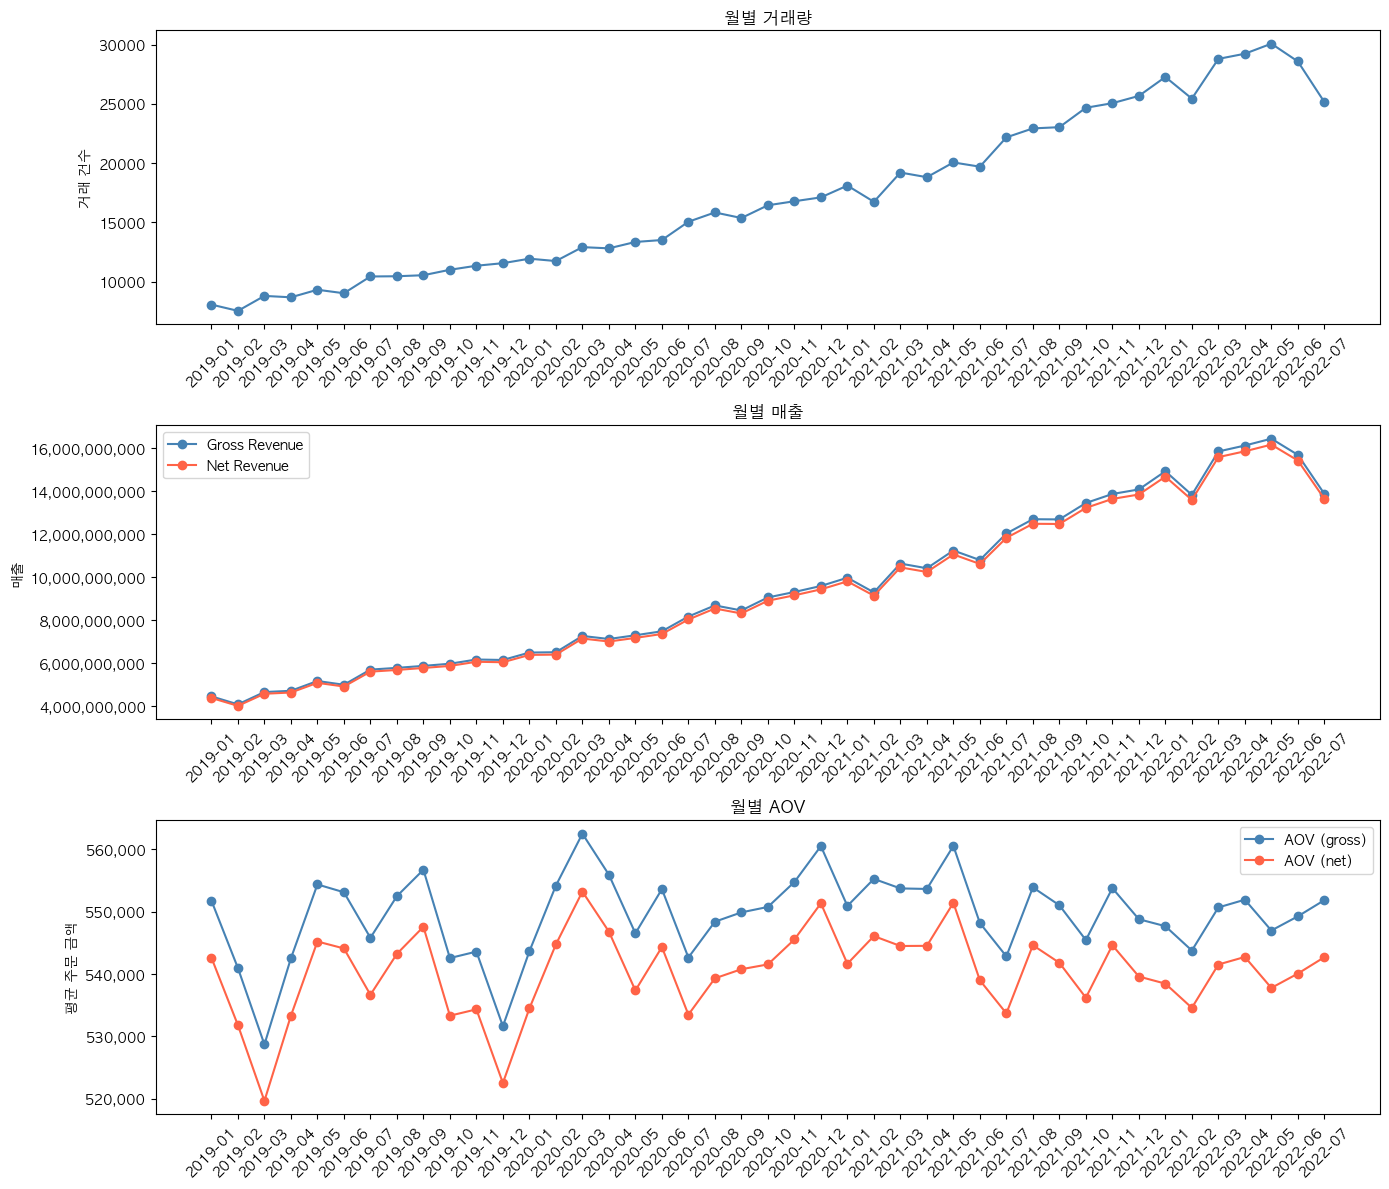

In [20]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12))
x = monthly_stats['year_month'].astype(str)

# 1. 월별 거래량
axes[0].plot(x, monthly_stats['order_cnt'], marker='o', color='steelblue')
axes[0].set_title('월별 거래량')
axes[0].set_ylabel('거래 건수')
axes[0].tick_params(axis='x', rotation=45)

# 2. 월별 매출 (gross vs net)
axes[1].plot(x, monthly_stats['gross_revenue'], marker='o', label='Gross Revenue', color='steelblue')
axes[1].plot(x, monthly_stats['net_revenue'],   marker='o', label='Net Revenue',   color='tomato')
axes[1].set_title('월별 매출')
axes[1].set_ylabel('매출')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:,.0f}'))
axes[1].legend()
axes[1].tick_params(axis='x', rotation=45)

# 3. AOV 추이
axes[2].plot(x, monthly_stats['aov'],     marker='o', label='AOV (gross)', color='steelblue')
axes[2].plot(x, monthly_stats['aov_net'], marker='o', label='AOV (net)',   color='tomato')
axes[2].set_title('월별 AOV')
axes[2].set_ylabel('평균 주문 금액')
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:,.0f}'))
axes[2].legend()
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

- 거래건수, 매출 : 2019년 이후 꾸준히 3배 이상 상승    
- AOV : 550,000원 내외에서 등락을 반복하며 **정체**

    ⇒ 매출 성장이 거래건수 증가에만 의존하고 있음  
    >   **AOV 정체의 원인 파악이 필요**

## 2. 가설 검증
-----

- ###  AOV 정체의 원인을 3가지 가설로 구조화

    | 가설 | 내용 | 핵심 질문 |
    |------|------|---------|
    | A. 신규고객 증가 | 신규고객이 늘면서 AOV 평균을 끌어내림 | 신규 vs 재구매 고객의 AOV 차이가 있는가? |
    | B. 프로모션 구조 문제 | 프로모션 의존도가 높아져 AOV 희석 | 프로모션 사용 시 AOV가 낮아지는가? |
    | C. 고가 세그먼트 이탈 | 고가 상품 구매층이 이탈하고 있음 | 고가 상품 구매 비율 감소하고 있는가? |

### A. 신규고객 증가로 AOV 평균이 낮아지는가?  
>        거래건수는 계속 오르는데 AOV는 정체  
>         → 새로운 고객이 계속 유입되고 있다는 신호  
>         → 신규고객은 보통 첫 구매라 소액 또는 탐색 구매를 하는 경향이 있음  
>         → 이게 AOV 평균을 끌어내릴 수 있다  

#### ⇒ 신규 vs 재구매 고객의 AOV 차이 비교

In [75]:
# 신규 고객 구분
# 1번 → 신규
# 2번 이상 → 재구매
transactions = transactions.sort_values('created_at')
transactions['purchase_rank'] = transactions.groupby('customer_id').cumcount() + 1
transactions['is_new'] = transactions['purchase_rank'] == 1

print(transactions['is_new'].value_counts())


is_new
False    692518
True      47995
Name: count, dtype: int64


In [76]:
# 연월별 거래량과 매출 합계 집계
monthly_segment = (transactions.groupby(['year_month', 'is_new']).agg(
    order_cnt = ('created_at', 'count'),  # 거래 건수
    gross_revenue = ('total_amount', 'sum'),       # 총매출 합계
    net_revenue = ('net_amount', 'sum'),       # 총매출 합계
    aov_mean=('total_amount', 'mean'),
    aov_median=('total_amount', 'median')
    ).reset_index()
)

monthly_segment['customer_type'] = monthly_segment['is_new'].map(
    {True: '신규', False: '재구매'}
)

# 결과 확인
display(monthly_segment)

,year_month,is_new,order_cnt,gross_revenue,net_revenue,aov_mean,aov_median,customer_type
0,2019-01,False,2199,1236476370,1216121370,562290.30,310125.00,재구매
1,2019-01,True,5868,3214743821,3161238821,547843.19,304550.50,신규
2,2019-02,False,4923,2677239299,2631979299,543822.73,301780.00,재구매
3,2019-02,True,2616,1401096258,1377241258,535587.25,302552.00,신규
4,2019-03,False,6826,3619917297,3557752297,530313.11,296401.50,재구매
5,2019-03,True,1974,1032616018,1015146018,523108.42,293060.00,신규
6,2019-04,False,7266,3951287435,3884377435,543805.04,304387.00,재구매
7,2019-04,True,1417,759461600,746336600,535964.43,302187.00,신규
8,2019-05,False,8046,4481618976,4408108976,556999.62,301945.00,재구매
9,2019-05,True,1274,685191562,673326562,537826.97,290744.00,신규


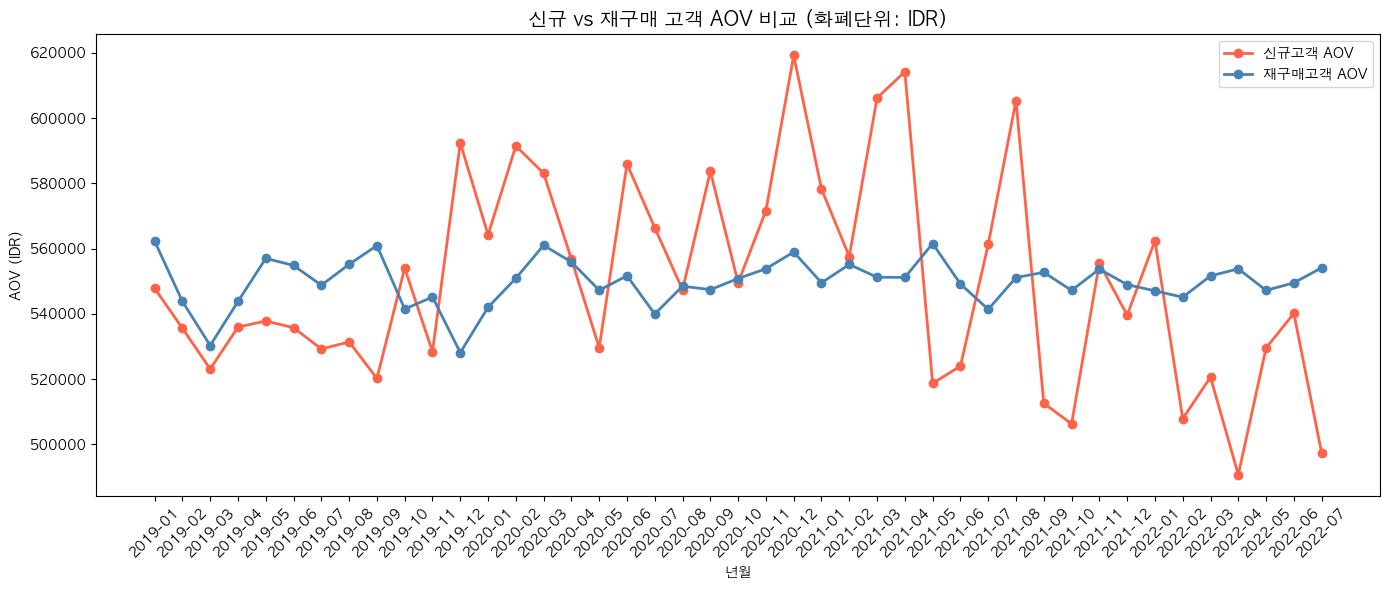

In [77]:
fig, axes = plt.subplots(1, 1, figsize=(14, 6))

# ── 차트 1 : 신규 vs 재구매 AOV (라인) ──────────────────
new_data = monthly_segment[monthly_segment['customer_type'] == '신규']
returning_data = monthly_segment[monthly_segment['customer_type'] == '재구매']

axes.plot(new_data['year_month'].astype(str), new_data['aov_mean'], marker='o', color="tomato", label='신규고객 AOV', linewidth=2)
axes.plot(returning_data['year_month'].astype(str), returning_data['aov_mean'], marker='o', color='steelblue', label='재구매고객 AOV', linewidth=2)

axes.set_title('신규 vs 재구매 고객 AOV 비교 (화폐단위: IDR)', fontsize=14)
axes.set_xlabel('년월')
axes.set_ylabel('AOV (IDR)')
axes.legend()

axes.tick_params(axis='x', rotation=45)


plt.tight_layout()
plt.show()

##### 신규고객 AOV 등락이 심하다  
1. 신규고객이 프로모션에 반응해서 구매하는 건 아닐까?  
>    - 예상 시나리오 :
>       - 프로모션 있을 때 신규유입 → AOV 낮아짐  
>       - 프로모션 없을 때 신규유입 → AOV 높아짐  
  
2. 신규고객은 증가 하는가?  

In [78]:
# 신규/재구매 고객의 프로모션 사용 여부
promo_segment = transactions.groupby(['is_new', 'promo_used']).agg(
    order_count=('created_at', 'count'),
    aov_mean=('total_amount', 'mean'),
    gross_revenue=('total_amount', 'sum')
).reset_index()

# 고객 타입별 전체 건수
total_by_type = transactions.groupby('is_new')['created_at'].count().reset_index()
total_by_type.columns = ['is_new', 'total_count']

promo_segment = promo_segment.merge(total_by_type, on='is_new')
#print(total_by_type)
#print(promo_segment)

promo_segment['promo_ratio'] = (
    promo_segment['order_count'] / promo_segment['total_count'] * 100
).round(2)

promo_segment['customer_type'] = promo_segment['is_new'].map(
    {True: '신규', False: '재구매'}
)
promo_segment['promo_type'] = promo_segment['promo_used'].map(
    {True: '사용', False: '미사용'}
)

print(promo_segment[['customer_type', 'promo_type', 'order_count', 'total_count', 'promo_ratio', 'aov_mean']])

  customer_type promo_type  order_count  total_count  promo_ratio  aov_mean
0           재구매        미사용       432931       692518        62.52 552194.98
1           재구매         사용       259587       692518        37.48 546393.53
2            신규        미사용        30954        47995        64.49 549386.80
3            신규         사용        17041        47995        35.51 545322.88


In [79]:
# 신규고객 비율이 증가하고 있는가?
monthly_new_ratio = transactions.groupby('year_month').agg(
    total=('created_at', 'count'),
    new=('is_new', 'sum')
).reset_index()
monthly_new_ratio['new_ratio'] = (monthly_new_ratio['new'] / monthly_new_ratio['total'] * 100).round(2)

#print(monthly_new_ratio)

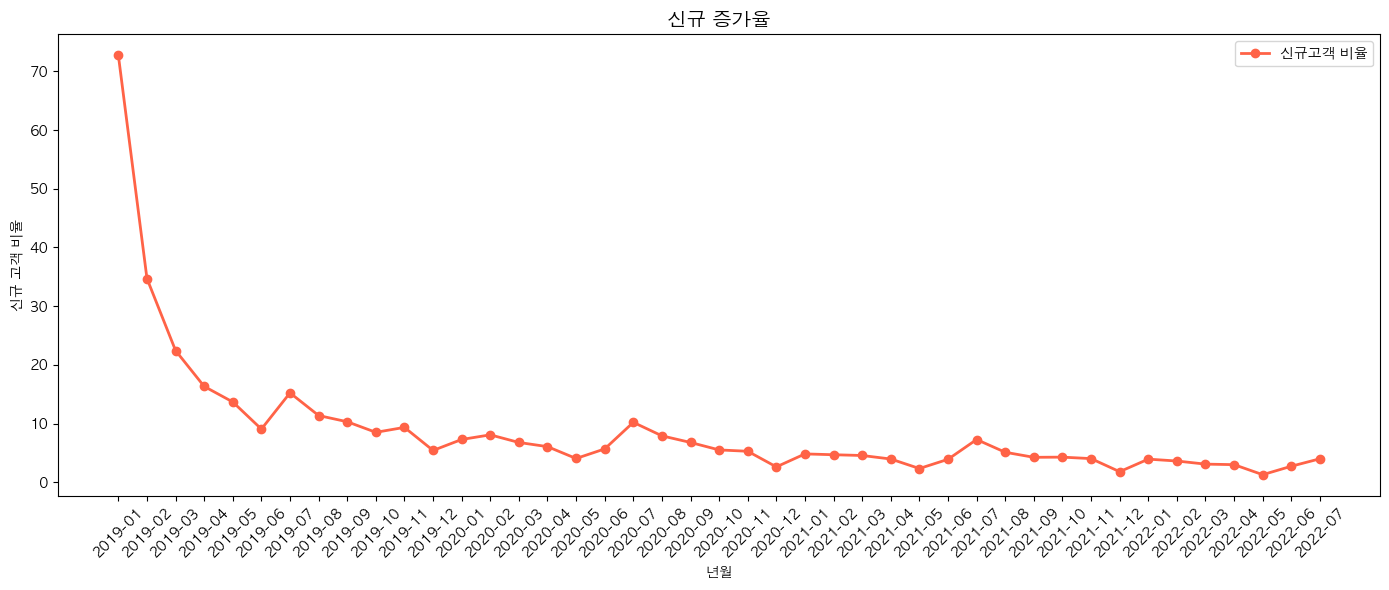

In [80]:
fig, axe = plt.subplots(1, 1, figsize=(14, 6))

# ── 차트 1 : 신규 vs 재구매 AOV (라인) ──────────────────

axe.plot(monthly_new_ratio['year_month'].astype(str), monthly_new_ratio['new_ratio'], marker='o', color="tomato", label='신규고객 비율', linewidth=2)


axe.set_title('신규 증가율', fontsize=14)
axe.set_xlabel('년월')
axe.set_ylabel('신규 고객 비율')
axe.legend()

axe.tick_params(axis='x', rotation=45)


plt.tight_layout()
plt.show()

1. 신규고객이 프로모션에 반응해서 구매하는 건 아닐까?  
>    - 신규 / 재구매 고객의 프로모션 사용비율이 비슷하다.
>    - AOV가 프로모션 여부와 상관없이 비슷하다.
  
2. 신규고객은 증가 하는가?  
>    - 오히려 줄고 있다. 

##### ⇒ 재구매 고객은 늘고 있는데 왜 AOV 안 오르는지..

1. 재구매 횟수가 늘수록 AOV가 높아지는가?  
    - 오래된 고객일수록 더 많이 쓰는가?

2. 재구매 고객의 리텐션은 유지되고 있는가?  
    - 재구매는 하는데 구매 주기가 길어지는 건 아닌가?

In [81]:
# 재구매별 AOV
purchase_rank_aov = transactions.groupby('purchase_rank').agg(
    order_count=('created_at', 'count'),
    aov_mean=('total_amount', 'mean')
).reset_index()

# 구매 20회까지만 보기 (구매수가 많을수록 고객수가 줄어듦)
purchase_rank_aov = purchase_rank_aov[purchase_rank_aov['purchase_rank'] <= 20]

print(purchase_rank_aov)

    purchase_rank  order_count  aov_mean
0               1        47995 547943.88
1               2        38810 551399.97
2               3        33601 546603.67
3               4        30000 554752.91
4               5        27285 546941.14
5               6        24965 549203.54
6               7        23012 548207.20
7               8        21335 547716.95
8               9        19871 549995.11
9              10        18608 554897.56
10             11        17483 549749.43
11             12        16495 565378.40
12             13        15597 539340.20
13             14        14777 564302.25
14             15        13974 553950.11
15             16        13290 548706.36
16             17        12662 556708.26
17             18        12077 547596.73
18             19        11511 557477.17
19             20        10957 555685.91


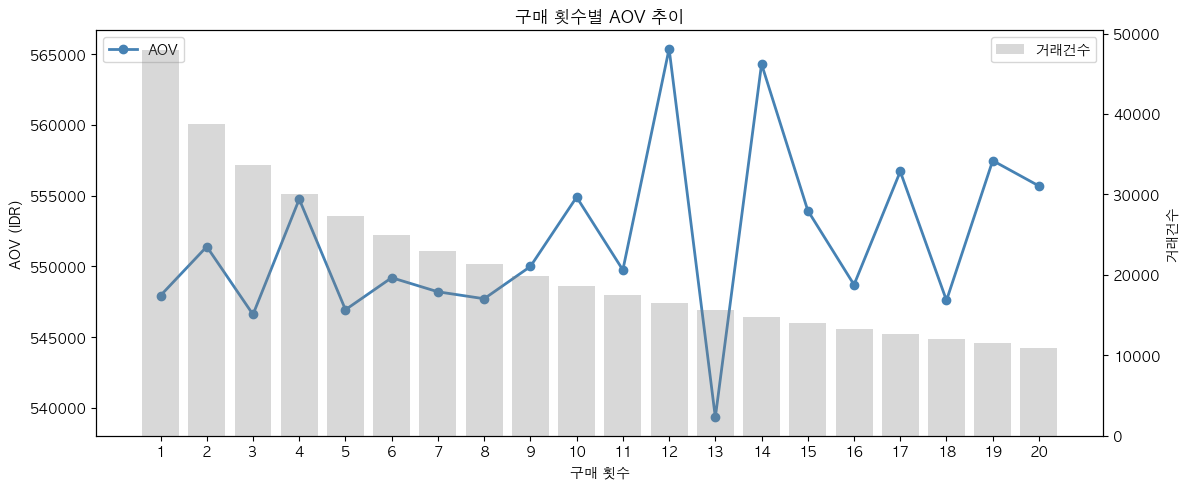

In [82]:
fig, ax1 = plt.subplots(figsize=(12, 5))

# AOV 라인
ax1.plot(purchase_rank_aov['purchase_rank'],
         purchase_rank_aov['aov_mean'],
         marker='o', color='steelblue', linewidth=2, label='AOV')
ax1.set_xlabel('구매 횟수')
ax1.set_ylabel('AOV (IDR)')
ax1.set_title('구매 횟수별 AOV 추이')


# 거래건수 막대 (보조축)
ax2 = ax1.twinx()
ax2.bar(purchase_rank_aov['purchase_rank'],
        purchase_rank_aov['order_count'],
        alpha=0.3, color='gray', label='거래건수')
ax2.set_ylabel('거래건수')

ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

ax1.set_xticks(range(1, 21))
ax1.set_xticklabels(range(1, 21))

plt.tight_layout()
plt.show()

In [83]:
# 고객별 첫 구매 월 (코호트 기준)
customer_cohort = transactions.groupby('customer_id')['created_at'].min().reset_index()
customer_cohort.columns = ['customer_id', 'cohort_date']
customer_cohort['cohort_month'] = customer_cohort['cohort_date'].dt.to_period('M')

# 트랜잭션에 코호트 월 붙이기
transactions = transactions.merge(customer_cohort[['customer_id', 'cohort_month']], 
                                   on='customer_id', how='left')

# 구매 월
transactions['purchase_month'] = transactions['created_at'].dt.to_period('M')

# 코호트 기준 몇 번째 달인지
transactions['period_number'] = (
    transactions['purchase_month'] - transactions['cohort_month']
).apply(lambda x: x.n)

# 리텐션 테이블 생성
cohort_data = transactions.groupby(['cohort_month', 'period_number'])['customer_id'].nunique().reset_index()
cohort_pivot = cohort_data.pivot_table(index='cohort_month', 
                                        columns='period_number', 
                                        values='customer_id')

# 리텐션 비율
cohort_size = cohort_pivot[0]
retention = cohort_pivot.divide(cohort_size, axis=0) * 100
retention = retention.round(2)

/var/folders/s8/ydysgqf95zvfb85flggqqzlw0000gn/T/ipykernel_80911/616513150.py:4: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  customer_cohort['cohort_month'] = customer_cohort['cohort_date'].dt.to_period('M')
/var/folders/s8/ydysgqf95zvfb85flggqqzlw0000gn/T/ipykernel_80911/616513150.py:11: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  transactions['purchase_month'] = transactions['created_at'].dt.to_period('M')


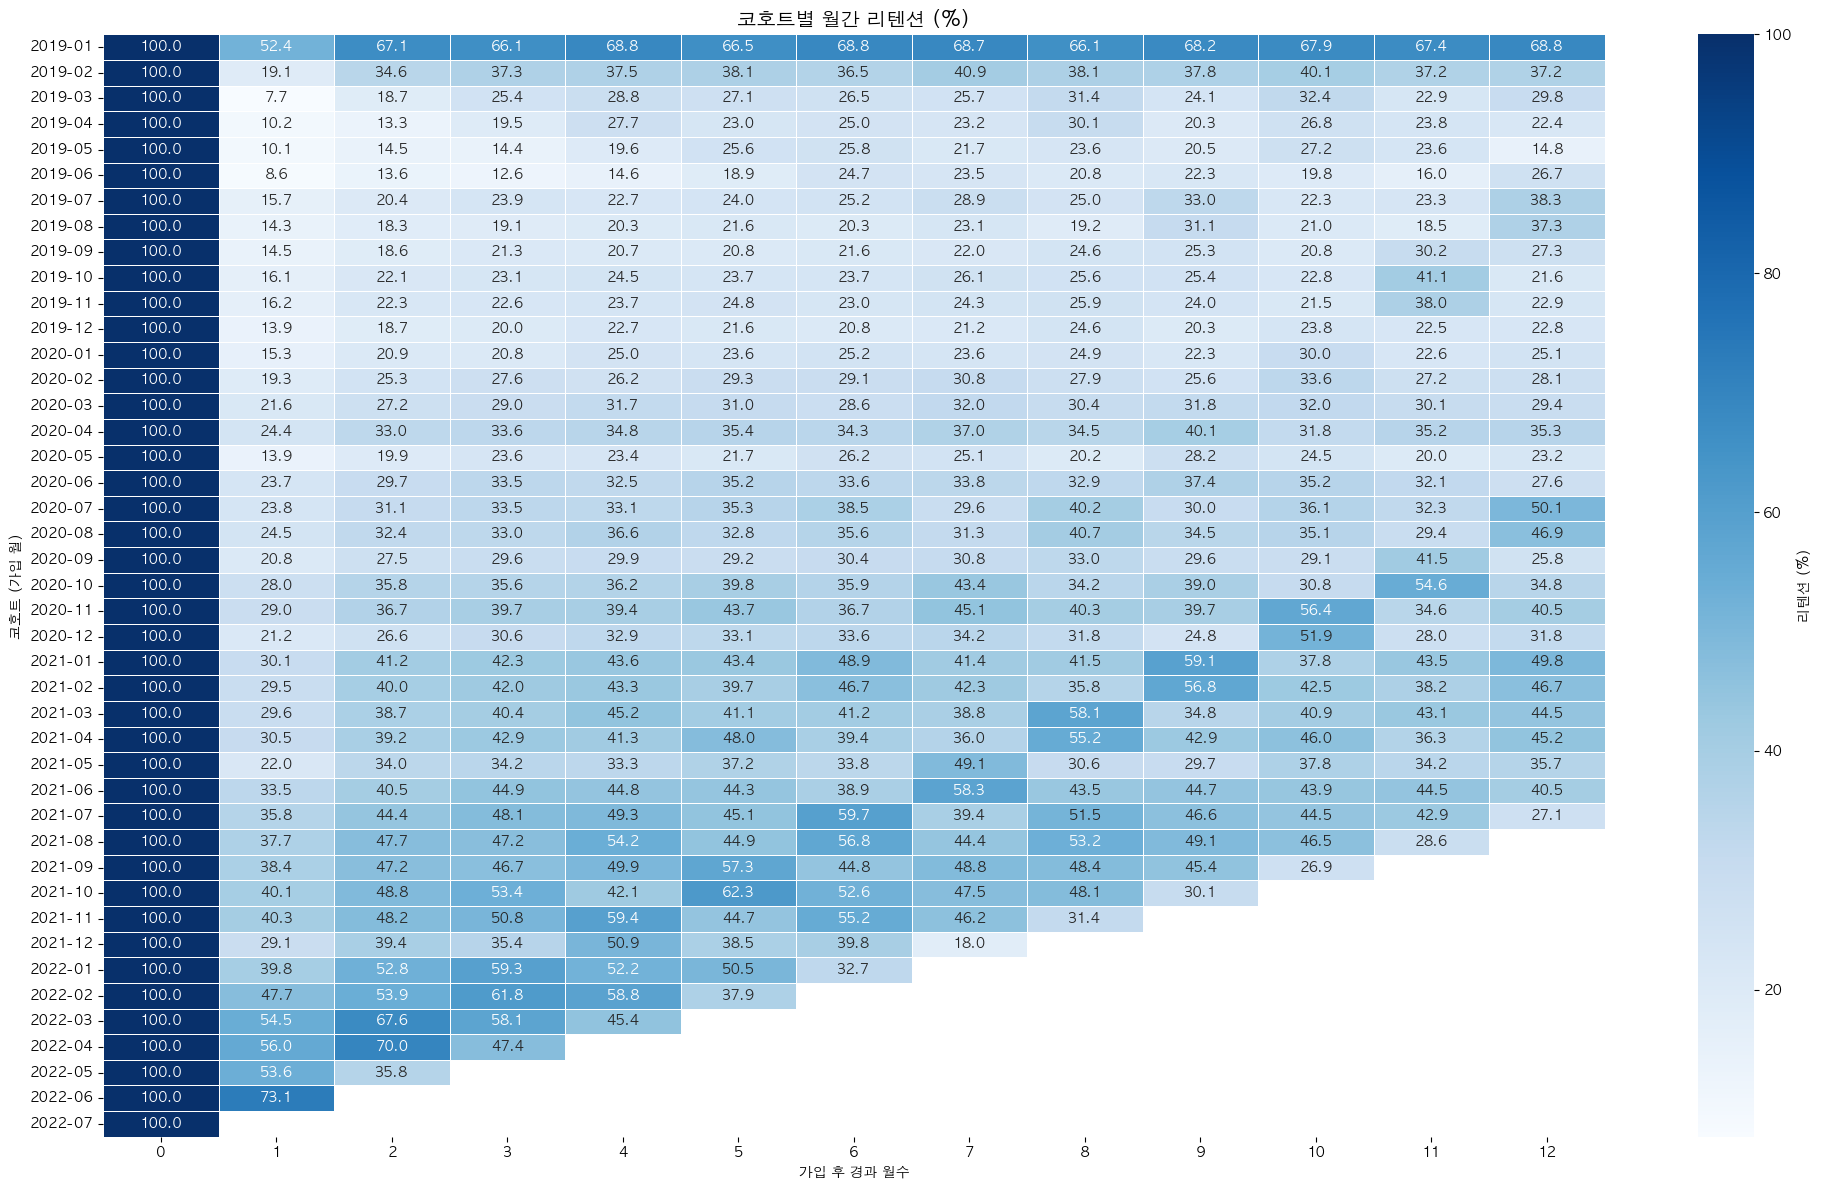

In [260]:
plt.figure(figsize=(20, 12))
sns.heatmap(retention.iloc[:, :13],  # 12개월까지만
            annot=True, fmt='.1f',
            cmap='Blues',
            linewidths=0.5,
            cbar_kws={'label': '리텐션 (%)'}
            )

plt.title('코호트별 월간 리텐션 (%)', fontsize=14)
plt.xlabel('가입 후 경과 월수')
plt.ylabel('코호트 (가입 월)')
plt.tight_layout()
plt.show()

In [85]:
# 코호트별 AOV 히트맵
cohort_aov = transactions.groupby(
    ['cohort_month', 'period_number'])['total_amount'].mean().reset_index()

cohort_aov_pivot = cohort_aov.pivot_table(
    index='cohort_month',
    columns='period_number',
    values='total_amount'
).round(0)

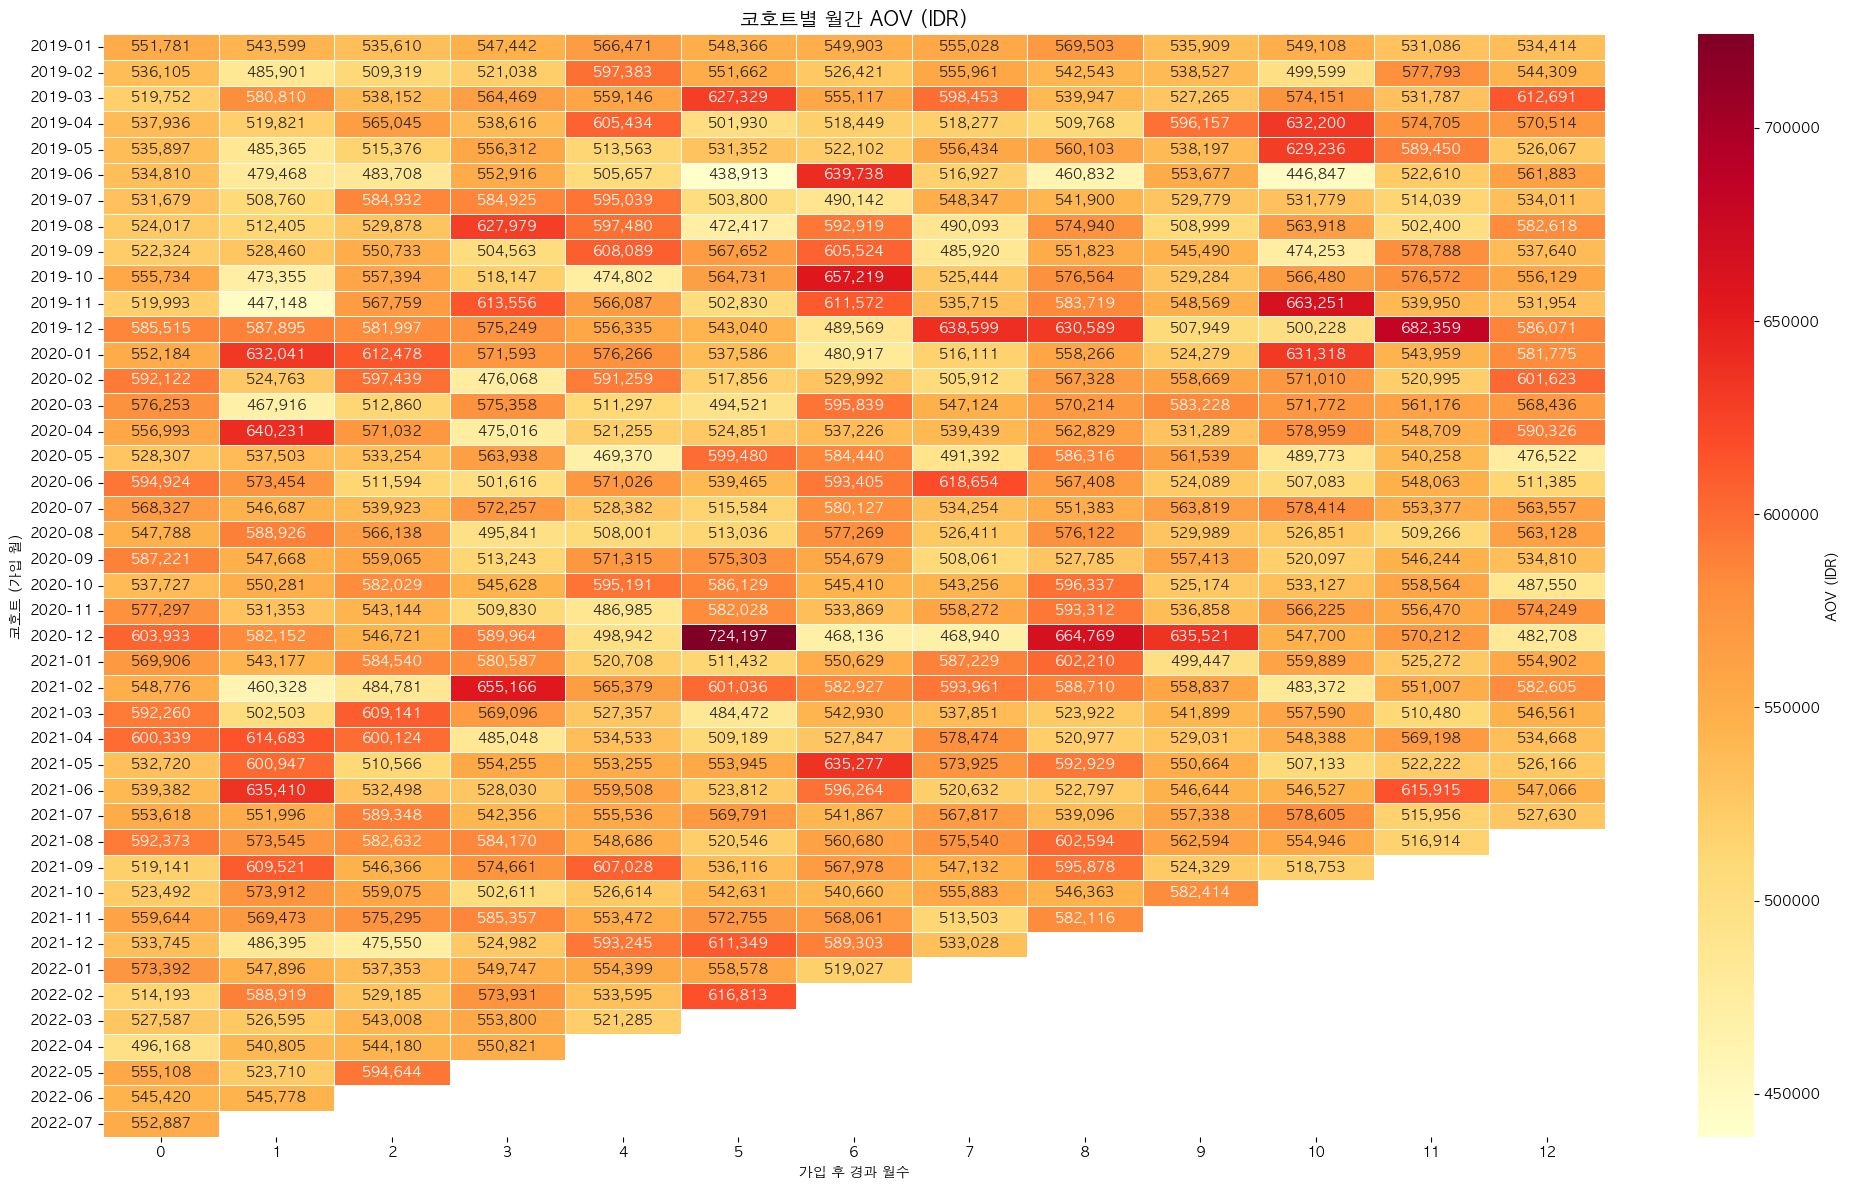

In [258]:
plt.figure(figsize=(20, 12))
sns.heatmap(cohort_aov_pivot.iloc[:, :13],
            annot=True, fmt=',.0f',
            cmap='YlOrRd',
            linewidths=0.5,
            cbar_kws={'label': 'AOV (IDR)'}
            )

plt.title('코호트별 월간 AOV (IDR)', fontsize=14)
plt.xlabel('가입 후 경과 월수')
plt.ylabel('코호트 (가입 월)')
plt.tight_layout()
plt.show()


### 가설 A 결론
**"신규고객 증가로 AOV 평균이 낮아지는가?"**

#### 분석 결과

1. 신규고객 비율
   - 2019년 초 72%에서 2022년 1~3%로 감소  
   - **신규고객 증가는 AOV 정체 원인 X**

2. 구매횟수별 AOV
   - 구매횟수 늘수록 AOV 높아지는 경향 있음 (뚜렷한 우상향은 아님). 
   - 재구매 자체가 AOV를 크게 올리지는 않음

3. 코호트별 리텐션
   - 초기고객(2019-01) 리텐션 매우 높음 (50~70%)
   - 2019 중반~2020 리텐션 낮음 (10~30%)
   - 2021 이후 리텐션 다시 회복 (40~60%)
   - 재구매 고객은 유지되고 있음

4. 코호트별 AOV
   - 특정 패턴 없음
   - 특정 코호트가 AOV를 낮추는 구조 아님
   - 재구매 고객은 유지되고 있으나 AOV는 정체  
     → 고객 자체가 아닌 구매 과정(퍼널)에 문제가 있을 가능성 확인 필요

5. 코호트 사선 패턴
   - 특정 시점에 여러 코호트 동시 활성화
   - 외부 요인 (프로모션/이벤트) 가능성

#### 종합 : 가설 A 기각
>   1. 신규고객, 재구매 고객 이탈 문제 X.  
>   2. 재구매 고객이 대부분인데 AOV가 안 오름.  
>   3. AOV를 끌어내리는 구조적 원인 존재.  
>   4. 프로모션 구조 문제 확인 필요. (가설 B)

### B. 프로모션 의존도가 높아져 AOV 희석 되는가?  
>       가설 A에서 신규고객 문제가 아님을 확인
>       → 재구매 고객이 대부분인데도 AOV는 정체
>       → 코호트 사선 패턴에서 특정 시점 동시 활성화 발견
>       → 외부 요인(프로모션/이벤트)이 구매를 유도하는 것 아닐까?
#### ⇒ 프로모션 사용 시 실제로 AOV가 낮아지는가?
#### ⇒ 프로모션 의존도가 시간이 갈수록 높아지고 있는가?

In [87]:
# 프로모션 사용 여부별 AOV
promo_aov = transactions.groupby('promo_used').agg(
    order_count=('created_at', 'count'),
    aov_mean=('total_amount', 'mean'),
    aov_median=('total_amount', 'median')
).reset_index()

promo_aov['promo_type'] = promo_aov['promo_used'].map(
    {True: '프로모션 사용', False: '프로모션 미사용'}
)

print(promo_aov[['promo_type', 'order_count', 'aov_mean', 'aov_median']])

  promo_type  order_count  aov_mean  aov_median
0   프로모션 미사용       463885 552007.60   305027.00
1    프로모션 사용       276628 546327.57   299729.00


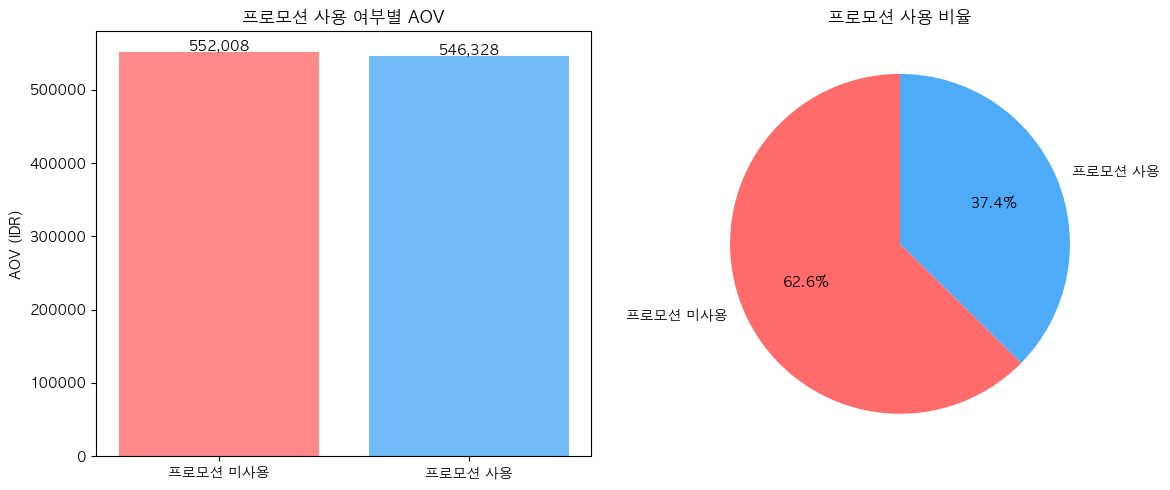

In [88]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 차트 1 - AOV 비교 막대
axes[0].bar(promo_aov['promo_type'],
            promo_aov['aov_mean'],
            color=['#FF6B6B', '#4DABF7'],
            alpha=0.8)
axes[0].set_title('프로모션 사용 여부별 AOV')
axes[0].set_ylabel('AOV (IDR)')
for i, v in enumerate(promo_aov['aov_mean']):
    axes[0].text(i, v + 1000, f'{v:,.0f}', 
                 ha='center', fontsize=10)

# 차트 2 - 거래건수 비율 파이
axes[1].pie(promo_aov['order_count'],
            labels=promo_aov['promo_type'],
            autopct='%1.1f%%',
            colors=['#FF6B6B', '#4DABF7'],
            startangle=90)
axes[1].set_title('프로모션 사용 비율')

plt.tight_layout()
plt.show()

In [89]:
# 월별 프로모션 사용 비율
monthly_promo = transactions.groupby('year_month').agg(
    order_count=('created_at', 'count'),
    promo_count=('promo_used', 'sum'),
    aov_mean=('total_amount', 'mean')
).reset_index()

monthly_promo['promo_ratio'] = (
    monthly_promo['promo_count'] / monthly_promo['order_count'] * 100
).round(2)

print(monthly_promo[['year_month', 'order_count', 'promo_count', 'promo_ratio', 'aov_mean']])

   year_month  order_count  promo_count  promo_ratio  aov_mean
0     2019-01         8067         3552        44.03 551781.36
1     2019-02         7539         3306        43.85 540965.06
2     2019-03         8800         3884        44.14 528696.97
3     2019-04         8683         3753        43.22 542525.51
4     2019-05         9320         4160        44.64 554378.81
5     2019-06         9025         4116        45.61 553121.38
6     2019-07        10440         4687        44.89 545813.15
7     2019-08        10459         4571        43.70 552501.98
8     2019-09        10546         4658        44.17 556733.37
9     2019-10        11006         4874        44.28 542564.18
10    2019-11        11347         5001        44.07 543598.10
11    2019-12        11562         5229        45.23 531630.42
12    2020-01        11941         5260        44.05 543649.14
13    2020-02        11742         5079        43.25 554190.99
14    2020-03        12916         5480        42.43 56

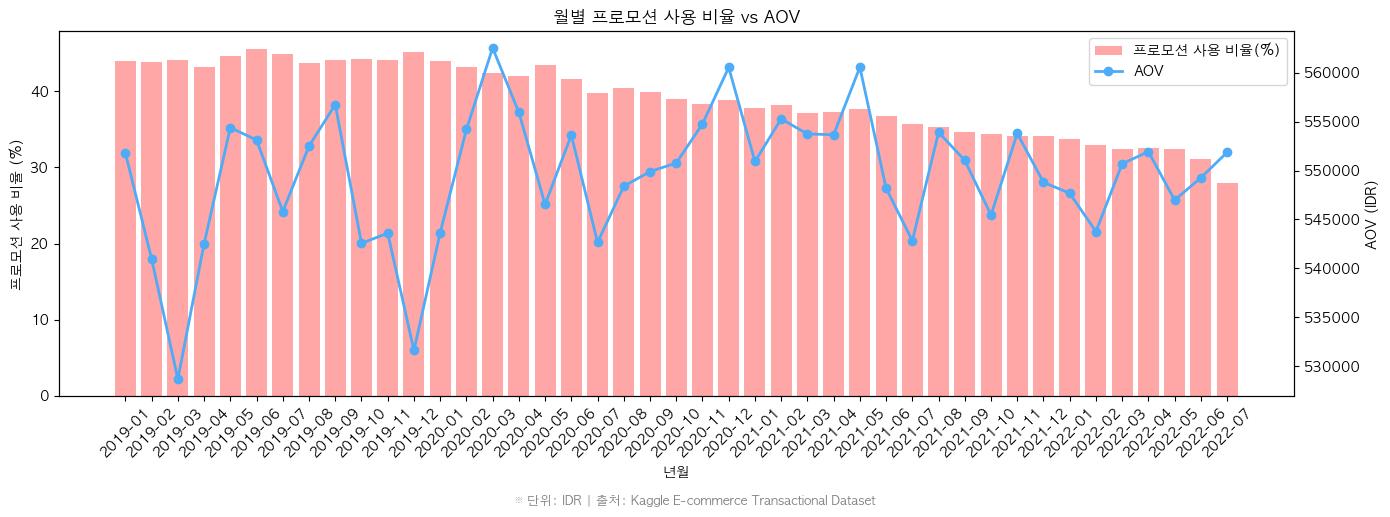

In [90]:
fig, ax1 = plt.subplots(figsize=(14, 5))

x = range(len(monthly_promo))

# 프로모션 사용 비율 막대
ax1.bar(x, monthly_promo['promo_ratio'],
        color='#FF6B6B', alpha=0.6, label='프로모션 사용 비율(%)')
ax1.set_ylabel('프로모션 사용 비율 (%)')
ax1.set_xlabel('년월')
ax1.set_xticks(list(x))
ax1.set_xticklabels(monthly_promo['year_month'].astype(str), rotation=45)

# AOV 라인 (보조축)
ax2 = ax1.twinx()
ax2.plot(x, monthly_promo['aov_mean'],
         color='#4DABF7', marker='o', linewidth=2, label='AOV')
ax2.set_ylabel('AOV (IDR)')

# 범례 합치기
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.title('월별 프로모션 사용 비율 vs AOV')
fig.text(0.5, -0.02,
         '※ 단위: IDR | 출처: Kaggle E-commerce Transactional Dataset',
         ha='center', fontsize=9, color='gray')

plt.tight_layout()
plt.show()

1. 프로모션 사용 시 실제로 AOV가 낮아지는가?  
>    - 약 1%(5,680 IDR)로 차이가 거의 없다 
  
2. 프로모션 의존도가 시간이 갈수록 높아지고 있는가?  
>    - 2019년 44% → 2022년 28%  
>    - 오히려 감소 추세


#### ⇒ 프로모션 여부는 AOV에 영향이 없다.

#### ▸ 그럼, 프로모션의 진짜 역할은 무엇인가?
1. CVR을 올리는가? 

In [ ]:
# click_stream에서 구매조건 확인
click_stream.head()

event_name
CLICK          2176750
HOMEPAGE       2158372
ADD_TO_CART    1647320
SCROLL         1453921
ITEM_DETAIL    1126164
SEARCH         1026648
BOOKING         740511
PROMO_PAGE      521107
ADD_PROMO       275592
Name: count, dtype: int64


,session_id,event_name,event_time,event_id,traffic_source,event_metadata,payment_status
0,fb0abf9e-fd1a-44dd-b5c0-2834d5a4b81c,HOMEPAGE,2019-09-06 15:54:32.821085+00:00,9c4388c4-c95b-4678-b5ca-e9cbc0734109,MOBILE,NaN,NaN
1,fb0abf9e-fd1a-44dd-b5c0-2834d5a4b81c,SCROLL,2019-09-06 16:03:57.821085+00:00,4690e1f5-3f99-42d3-84a5-22c4c4d8500a,MOBILE,NaN,NaN
2,7d440441-e67a-4d36-b324-80ffd636d166,HOMEPAGE,2019-09-01 12:05:10.322763+00:00,88aeaeb5-ec98-4859-852c-8abb483faf31,MOBILE,NaN,NaN
3,7d440441-e67a-4d36-b324-80ffd636d166,ADD_TO_CART,2019-09-01 12:06:33.322763+00:00,934e306e-ecc6-472f-9ccb-12c8536910a2,MOBILE,"{'product_id': 15315, 'quantity': 4, 'item_pri...",NaN
4,7d440441-e67a-4d36-b324-80ffd636d166,BOOKING,2019-09-01 12:15:29.425431+00:00,9f4767a1-40fa-4c9c-9524-dfad18634d56,MOBILE,{'payment_status': 'Success'},Success


In [92]:
import ast

# event_metadata에서 payment_status 추출
def get_payment_status(metadata):
    try:
        if pd.isna(metadata):
            return None
        data = ast.literal_eval(metadata)
        return data.get('payment_status', None)
    except:
        return None
click_stream['payment_status'] = click_stream['event_metadata'].apply(get_payment_status)

# 세션별 이벤트 + 결제 성공 여부
session_funnel = click_stream.groupby('session_id').apply(
    lambda x: pd.Series({
        'used_promo': 'ADD_PROMO' in x['event_name'].values,
        'purchased': (
            (x['event_name'] == 'BOOKING') & 
            (x['payment_status'] == 'Success')
        ).any()
    })
).reset_index()


In [93]:
# click_stream 기준 프로모션 사용 세션
promo_sessions = click_stream[
    click_stream['event_name'] == 'ADD_PROMO'
]['session_id'].unique()

# session_id로 transactions에 붙이기
transactions['promo_used_click_stream'] = transactions['session_id'].isin(promo_sessions)

# 두 테이블간 프로모션 여부 비교 
compare = transactions.groupby(['promo_used', 'promo_used_click_stream']).size().reset_index(name='count')
print(compare)

   promo_used  promo_used_click_stream   count
0       False                    False  463885
1        True                    False    1036
2        True                     True  275592


##### 프로모션 기준 일치 여부 검증
- transactions 기준 vs click_stream ADD_PROMO 이벤트 기준 비교
- 불일치 1,036건 (전체의 0.4%)
- click_stream 이벤트 수집 누락으로 추측
- CVR에 미치는 영향 미미

In [94]:
# CVR 계산
cvr_by_promo = session_funnel.groupby('used_promo').agg(
    total_session=('session_id', 'count'),
    purchased=('purchased', 'sum')
).reset_index()

cvr_by_promo['cvr'] = (
    cvr_by_promo['purchased'] / cvr_by_promo['total_session'] * 100
).round(2)

cvr_by_promo['promo_type'] = cvr_by_promo['used_promo'].map(
    {True: '프로모션 사용', False: '프로모션 미사용'}
)

print(cvr_by_promo[['promo_type', 'total_session', 'purchased', 'cvr']])

  promo_type  total_session  purchased   cvr
0   프로모션 미사용         496203     444875 89.66
1    프로모션 사용         275592     263812 95.73


1. CVR을 올리는가? 
>    - 차이 : 약 6% 
>    - 프로모션 사용시 CVR 증가

#### 프로모션의 역할
>    - 구매 망설이는 고객을 전환시키는 역할
>    - 단가를 높이는 역할은 못함


#### ▸ 그럼 프로모션 구조(할인 구간)에 따라 AOV에 영향이 있는가?

1. 할인 구간별 비교
    - [total_amount]는 이미 할인이 적용된 금액이므로  
    **상품 단가 기준**으로 확인 필요

In [95]:
# 상품 단가 확인
print(product.info())

<class 'pandas.DataFrame'>
RangeIndex: 44424 entries, 0 to 44423
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  44424 non-null  int64  
 1   gender              44424 non-null  str    
 2   masterCategory      44424 non-null  str    
 3   subCategory         44424 non-null  str    
 4   articleType         44424 non-null  str    
 5   baseColour          44409 non-null  str    
 6   season              44403 non-null  str    
 7   year                44423 non-null  float64
 8   usage               44107 non-null  str    
 9   productDisplayName  44417 non-null  str    
dtypes: float64(1), int64(1), str(8)
memory usage: 3.4 MB
None


#### product 테이블에 단가 컬럼 없음
####  **transactions에서 단가 역산**


In [165]:
# transactions['metadata_parsed'] 파싱
import ast

def parse_metadata(metadata):
    try:
        return ast.literal_eval(metadata)
    except:
        return []

transactions['metadata_parsed'] = transactions['product_metadata'].apply(parse_metadata)

# 필요한 컬럼만
cols = [
    'booking_id',
    'metadata_parsed',
    'year_month',
    'customer_id',
    'net_amount'
]

# 상품별로 행 펼치기 (explode)
transactions_exploded = transactions[cols].explode('metadata_parsed').copy()

# product_id, item_price, quantity 추출
transactions_exploded['product_id'] = transactions_exploded['metadata_parsed'].apply(
    lambda x: x.get('product_id', None) if isinstance(x, dict) else None
)
transactions_exploded['item_price'] = transactions_exploded['metadata_parsed'].apply(
    lambda x: x.get('item_price', None) if isinstance(x, dict) else None
)
transactions_exploded['quantity'] = transactions_exploded['metadata_parsed'].apply(
    lambda x: x.get('quantity', None) if isinstance(x, dict) else None
)

print(transactions_exploded[['booking_id', 'product_id', 'item_price', 'quantity']].head(10))
print(f"원본 행수: {len(transactions)}")
print(f"explode 후 행수: {len(transactions_exploded)}")

                             booking_id  product_id  item_price  quantity
0  790bca1f-d76c-4641-bc7e-7674323ea579       26182      131827         1
1  c6f1e5df-bd15-4e0e-be0a-a9e2a5cb3b82       46931      343876         3
2  249aa61e-5fee-4686-99ef-fbc5a17ddb4b       21623      232447         1
3  2a411748-9ce2-4092-810c-5b1e8ea811b8       46060      263017         2
4  fc8fd52a-cd88-4377-b691-4beb9ef7c24b       44762      583463         1
5  77ca06d5-a6ca-4132-85e4-21fff8551fa7       30196      355026         1
6  3cd25521-e6d4-44d8-9cb7-3b3aa7de14cc       49521      169630         1
7  a3811c17-7652-4c97-a2b2-3bec36943e9a       42834      302111         1
7  a3811c17-7652-4c97-a2b2-3bec36943e9a       25364      474178         1
8  1aa772e2-5ba8-4ca0-9af0-ea320b8f505d       39981      101528         1
원본 행수: 740513
explode 후 행수: 1089586


In [166]:
# 실제 단가 계산
transactions_exploded['unit_price'] = (
    transactions_exploded['item_price'] / transactions_exploded['quantity']
)
#print(transactions_exploded[['product_id', 'quantity', 'item_price', 'unit_price']].head(10))

In [168]:
# 1. transactions에서 할인율 계산
transactions['discount_rate'] = (
    transactions['promo_amount'] / 
    (transactions['total_amount'] + transactions['promo_amount']) * 100
).fillna(0)

# 할인율 구간화
transactions['discount_band'] = pd.cut(
    transactions['discount_rate'],
    bins=[-0.001, 0, 1, 3, 5, 10, 100],
    labels=['할인없음', '0~1%', '1~3%', '3~5%', '5~10%', '10%+']
)

In [169]:
# 거래당 평균 unit_price
booking_avg_price = transactions_exploded.groupby('booking_id').agg(
    avg_unit_price=('unit_price', 'mean')
).reset_index()

# discount_band 붙이기
booking_avg_price = booking_avg_price.merge(
    transactions[['booking_id', 'discount_band', 'discount_rate']],
    on='booking_id', how='left'
)

# 할인율 구간별 평균 단가
discount_price = booking_avg_price.groupby('discount_band').agg(
    order_count=('booking_id', 'count'),
    avg_unit_price=('avg_unit_price', 'mean'),
    avg_discount=('discount_rate', 'mean')
).reset_index()

print(discount_price)

  discount_band  order_count  avg_unit_price  avg_discount
0          할인없음       463885       222494.17          0.00
1          0~1%        91609       228722.06          0.54
2          1~3%       131165       243407.87          1.81
3          3~5%        36879       177028.53          3.79
4         5~10%        15165       128479.53          6.52
5          10%+         1810        80356.48         12.97


/var/folders/s8/ydysgqf95zvfb85flggqqzlw0000gn/T/ipykernel_80911/453692154.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_by_band,


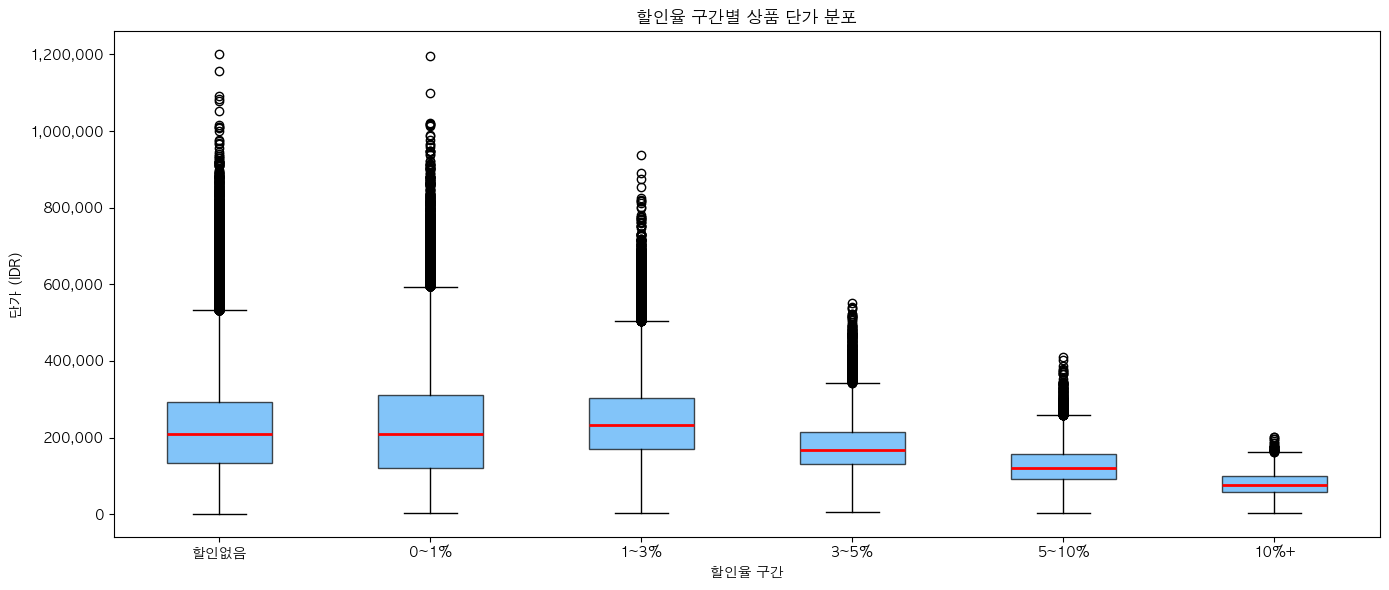

                count    mean     std   min     25%     50%     75%      max
discount_band                                                               
할인없음           682177  222526  120792  1250  134173  208769  294049  1200357
0~1%           210565  225992  135936  2402  121073  210177  310397  1196775
1~3%           142588  240556  104497  2863  169123  232669  303474   937829
3~5%            37250  176751   67862  6761  129855  168922  215319   551098
5~10%           15196  128461   50923  3834   91895  120907  158320   410774
10%+             1810   80356   32704  2041   56941   76058   99341   200997


In [170]:
# 상품 단가별 분포를 보기 위해서 transactions_exploded에 discount_band 붙이기
exploded_with_band = transactions_exploded.merge(
    transactions[['booking_id', 'discount_band']],
    on='booking_id',
    how='left'
)

# 박스플롯
fig, ax = plt.subplots(figsize=(14, 6))

bands = ['할인없음', '0~1%', '1~3%', '3~5%', '5~10%', '10%+']
data_by_band = [
    exploded_with_band[
        exploded_with_band['discount_band'] == band
    ]['unit_price'].values
    for band in bands
]

ax.boxplot(data_by_band,
           labels=bands,
           patch_artist=True,
           boxprops=dict(facecolor='#4DABF7', alpha=0.7),
           medianprops=dict(color='red', linewidth=2))

ax.set_title('할인율 구간별 상품 단가 분포')
ax.set_xlabel('할인율 구간')
ax.set_ylabel('단가 (IDR)')
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'{int(x):,}')
)

plt.tight_layout()
plt.show()

discount_summary = exploded_with_band.groupby('discount_band')['unit_price'].describe().astype(int)
print(discount_summary)

1. 그럼 프로모션 구조(할인 구간)에 따라 AOV에 영향이 있는가?
    - 할인율이 높아질수록 상품 단가 중앙값이 하락
#### ⇒ 고율 할인이 저가 상품에 집중되어 AOV 희석

### 가설 B 결론
**"프로모션 의존도가 높아져 AOV가 희석되는가?"**

#### 분석 결과

1. 프로모션 사용 여부별 AOV
   - 미사용 552,008 / 사용 546,328
   - 차이 약 1% → 유의미한 차이 X 

2. 프로모션 사용 비율 월별 추이
   - 2019년 44% → 2022년 28%
   - 오히려 감소 추세

3. 프로모션 사용 여부별 CVR
   - 미사용 89.66% / 사용 95.73%
   - 프로모션 사용 시 CVR 약 6%p 높음

4. 할인율 구간별 상품 단가 분포
   - 할인율 3% 이상부터 저가 상품 위주
   - 소폭 할인(1~3%)은 오히려 고가 상품 구매 유도
   - 고율 할인이 저가 상품 구매를 촉진하는 구조

#### 종합
>   1. 프로모션 여부가 AOV에는 영향 없음.  
>   2. 프로모션 의존도도 높아지지 않음.  
>   3. 프로모션은 CVR을 올리는 역할만 함.  
>   4. 단, 고율 할인(3%+) 구간에서 저가 상품 구매 집중
>   5. 그렇다면 고가 상품 구매는 누가 하고 있는가? (가설 C) 
#### ✓ **할인 정책 구조가 AOV 상승을 제한할 가능성**


### C. 고가 상품 구매 비율 감소하고 있는가? 
>   - 가설 A 기각, 가설 B에서 고율 할인이 저가 상품 구매를 유도하는 구조 확인
>       1. 저가 상품 구매가 늘고 있다면, 고가 상품 구매는 줄고 있는 것이 아닐까?  
>       2. 고가 상품 구매 비율이 줄면 거래건수가 늘어도 AOV는 정체될 수 있음  

#### ⇒ 고가 상품 구매 비율이 감소하고 있는가?
#### ⇒ 어떤 카테고리가 고가 구매를 이끄는가?

In [171]:
# transactios_exploded의 상품 단가를 product로 조인 
product_unit_price = product.merge(
    transactions_exploded[['product_id', 'unit_price', 'year_month']],
    left_on = 'id',
    right_on = 'product_id',
    how='left'
)

#print(product_unit_price.sort_values(['product_id','year_month'], ascending=True).head(30))
print(product_unit_price[product_unit_price['product_id']==1163].sort_values(['year_month'], ascending=True))
#print(transactions_exploded[['year_month', 'created_at', 'product_id', 'item_price', 'quantity', 'unit_price']].sort_values(['product_id','year_month'], ascending=True).head(20))

          id gender masterCategory subCategory articleType baseColour  season  \
316745  1163    Men        Apparel     Topwear     Tshirts       Blue  Summer   
316746  1163    Men        Apparel     Topwear     Tshirts       Blue  Summer   
316747  1163    Men        Apparel     Topwear     Tshirts       Blue  Summer   
316748  1163    Men        Apparel     Topwear     Tshirts       Blue  Summer   
316749  1163    Men        Apparel     Topwear     Tshirts       Blue  Summer   
316750  1163    Men        Apparel     Topwear     Tshirts       Blue  Summer   
316751  1163    Men        Apparel     Topwear     Tshirts       Blue  Summer   
316752  1163    Men        Apparel     Topwear     Tshirts       Blue  Summer   
316753  1163    Men        Apparel     Topwear     Tshirts       Blue  Summer   
316754  1163    Men        Apparel     Topwear     Tshirts       Blue  Summer   
316755  1163    Men        Apparel     Topwear     Tshirts       Blue  Summer   
316757  1163    Men        A

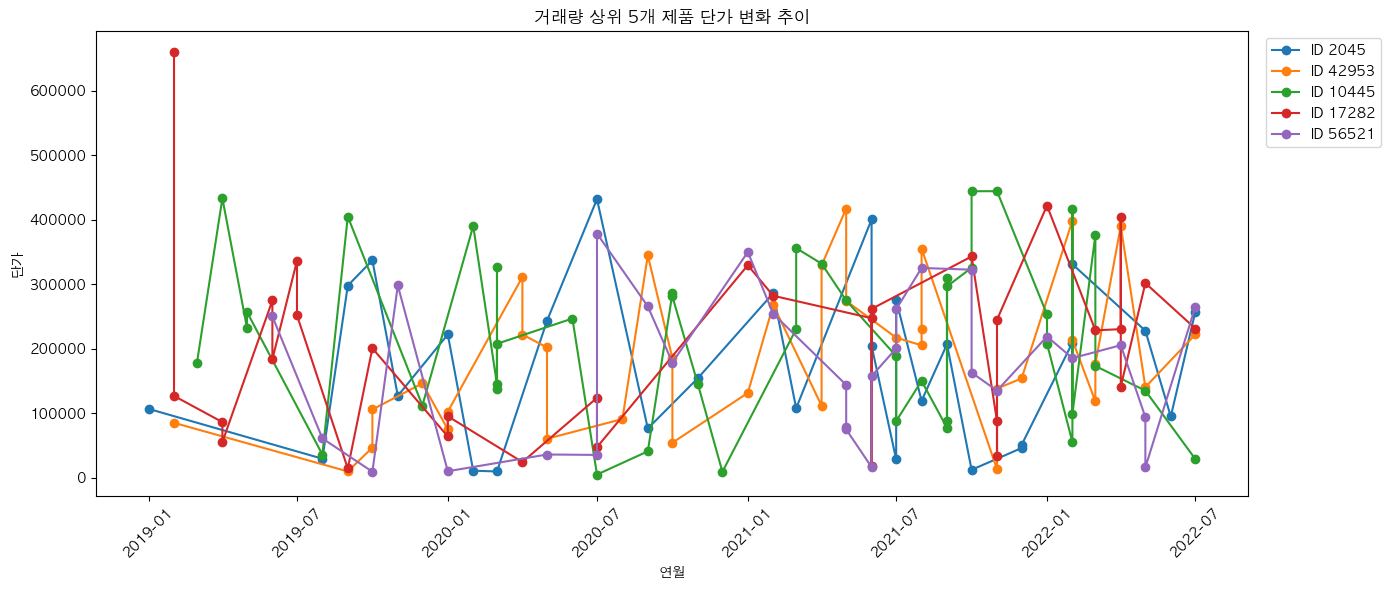

In [172]:
# 거래량 상위 5개 제품
top5_product = (
    transactions_exploded.groupby('product_id')['quantity']
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .index
)

# 필터링
price_top5 = product_unit_price[product_unit_price['product_id'].isin(top5_product)]

fig, ax = plt.subplots(figsize=(14, 6))

for pid in top5_product:
    data = price_top5[price_top5['product_id'] == pid].sort_values('year_month')
    x = data['year_month'].dt.to_timestamp()
    ax.plot(x, data['unit_price'], marker='o', label=f'ID {int(pid)}', linewidth=1.5)

ax.set_title('거래량 상위 5개 제품 단가 변화 추이')
ax.set_xlabel('연월')
ax.set_ylabel('단가')
ax.tick_params(axis='x', rotation=45)
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

#### 데이터 검증 과정에서 발견한 데이터 구조
- tansactions의 거래마다 동일 상품의 단가가 일정하지 않고 들쭉날쭊함.
- 예시) product_id 2045 : 10,059 - 431,914 IDR로 들쭉날쭉
- 상품 단가로 고가 세그먼트 기준 정의 불가
#### ⇒ 상품별 평균 단가로 고가 세그먼트 기준 정의

In [176]:
# 상품별 평균 단가
product_avg_price = product_unit_price.groupby('product_id').agg(
    avg_unit_price=('unit_price', 'mean')
).reset_index()

#print(product_avg_price.sort_values(['avg_unit_price'], ascending=False))

# 고가 기준 = 상위 25%
q75 = product_avg_price['avg_unit_price'].quantile(0.75)
product_avg_price['is_premium'] = (
    product_avg_price['avg_unit_price'] >= q75
)

print(f"고가 기준: {q75:,.0f} IDR 이상")
print(product_avg_price['is_premium'].value_counts())

# transactions_exploded에 is_premium 붙이기
transactions_priemium = transactions_exploded.merge(
    product_avg_price[['product_id', 'is_premium']],
    on='product_id',
    how='left'
)

# 월별 고가 구매 비율
monthly_premium = transactions_priemium.groupby('year_month').agg(
    total=('booking_id', 'count'),
    premium=('is_premium', 'sum')
).reset_index()

monthly_premium['premium_ratio'] = (
    monthly_premium['premium'] / monthly_premium['total'] * 100
).round(2)

#print(monthly_premium)

고가 기준: 238,570 IDR 이상
is_premium
False    33318
True     11106
Name: count, dtype: int64


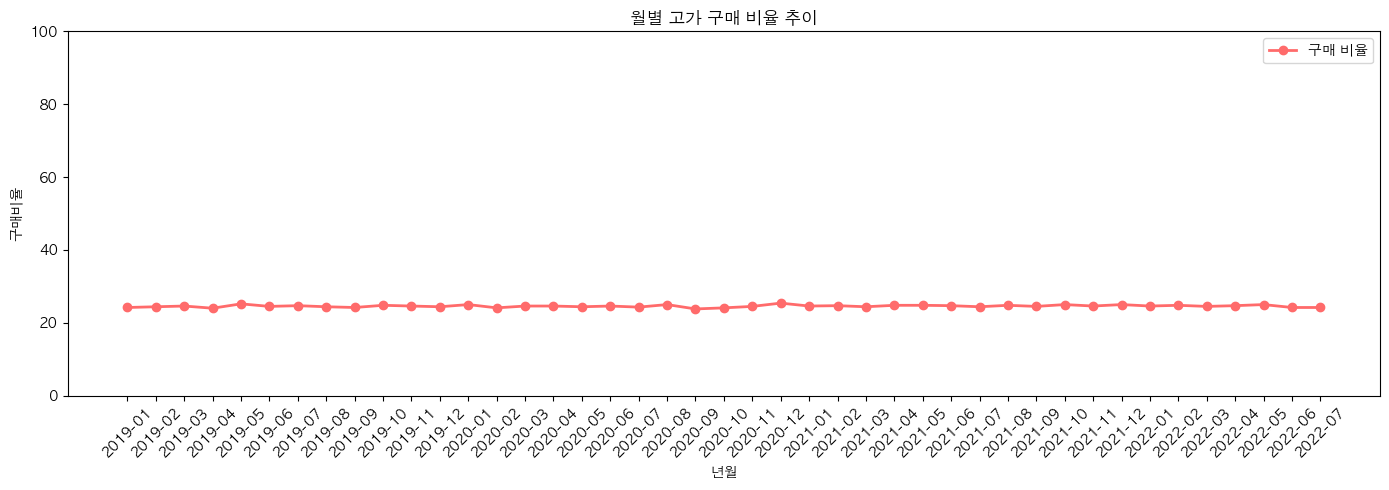

In [175]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(range(len(monthly_premium)),
        monthly_premium['premium_ratio'].round(1),
        marker='o', linewidth=2,
        color='#FF6B6B', label='구매 비율')


ax.set_title('월별 고가 구매 비율 추이')
ax.set_ylabel('구매비율')
ax.set_xlabel('년월')
ax.set_xticks(range(len(monthly_premium)))
ax.set_xticklabels(monthly_premium['year_month'].astype(str), rotation=45)
ax.set_ylim(0, 100) 
ax.legend()


plt.tight_layout()
plt.show()

In [178]:
# transactions_priemium에 카테고리 붙이기
transactions_premium_Category = transactions_priemium.merge(
    product[['id', 'masterCategory', 'subCategory']],
    left_on='product_id',
    right_on='id',
    how='left'
)

# masterCategory 기준으로 고가 구매 비율
category_premium = transactions_premium_Category.groupby('masterCategory').agg(
    total=('booking_id', 'count'),
    premium=('is_premium', 'sum')
).reset_index()

category_premium['premium_ratio'] = (
    category_premium['premium'] / category_premium['total'] * 100
).round(2)

category_premium = category_premium.sort_values(
    'premium_ratio', ascending=False)

print(category_premium)

   masterCategory   total premium premium_ratio
6  Sporting Goods     589     171         29.03
2        Footwear  226414   56409         24.91
1         Apparel  524924  129796         24.73
0     Accessories  275586   67449         24.47
5   Personal Care   58914   13658         23.18
3      Free Items    2592     514         19.83
4            Home      18       0          0.00


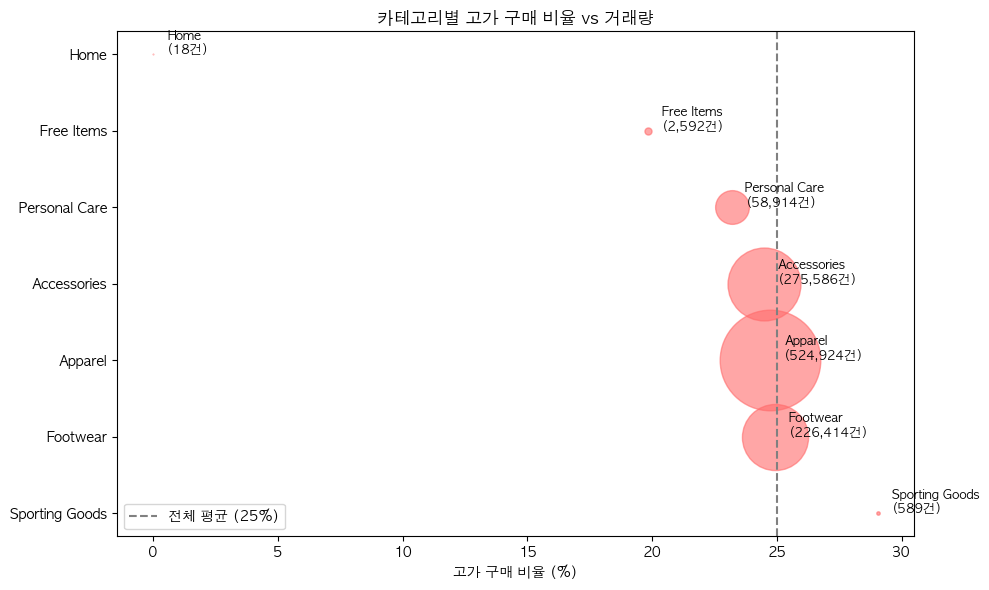

In [179]:
fig, ax = plt.subplots(figsize=(10, 6))

for _, row in category_premium.iterrows():
    ax.scatter(row['premium_ratio'], 
               row['masterCategory'],
               s=row['total']/100,  # 버블 크기 = 거래량
               alpha=0.6,
               color='#FF6B6B')
    ax.annotate(f"{row['masterCategory']}\n({row['total']:,}건)",
                (row['premium_ratio'], row['masterCategory']),
                textcoords='offset points',
                xytext=(10, 0), fontsize=9)

ax.axvline(x=25, color='gray', linestyle='--', label='전체 평균 (25%)')
ax.set_title('카테고리별 고가 구매 비율 vs 거래량')
ax.set_xlabel('고가 구매 비율 (%)')
ax.legend()

plt.tight_layout()
plt.show()

1. 고가 상품 구매 비율이 감소하고 있는가? 
>    - 25% 일정하게 나타남
  
2. 어떤 카테고리가 고가 구매를 이끄는가?
>    - 주력 카테고리 (Apparel/Footwear/Accessories) : 모두 25% 내외로 균일
>    - Sporting Goods만 29%지만  
>      거래량 589건으로 전체의 0.05%

#### ⇒ 고가 상품 구매비율 일정하고 특정 카테고리가 고가 구매를 이끄는 구조 아님.

### 가설 C 결론
**"고가 상품 구매 비율 감소하고 있는가?"**

#### 분석 결과

1. 상품별 평균 단가 기준 고가 정의
   - 데이터 검증 과정에서 같은 상품도 거래마다 단가가 다름
   - 상품 단가로 고가 세그먼트 기준 정의 불가
   - 상품별 평균 단가로 상위 25% 기준 고가 세그먼트 기준 정의

2. 월별 고가 구매 비율 추이
   - 기간 내 구매 비율도 약 25% 수준으로 일정

3. 카테고리별 고가 상품 구매 비율 비교
   - 주력 카테고리가 25% 내외로 분포
   - 29%인 카테고리가 있었지만 거래건수가 현저히 낮음

#### 종합 : 가설 C 기각
>   1. 고가 세그먼트 구매 이탈이 없음.  
>   2. 카테고리별 고가 세그먼트 구매비율 균일.  
>   3. 고가 세그먼트는 AOV에 주요 원인으로 보기는 어려움.  


### ▸ 가설 A/C 기각, 가설 B에서 고율 할인 구간에 저가 상품 집중 확인
### ▸ 고가 상품을 구매하는 고객층은 누구인가?
### ⇒ 고객 세그먼트별 AOV 차이 확인

## 3. 세그먼트 분석
-----

### 분석 개요
- 가설 B에서 고율 할인 구간에 저가 상품 집중 확인
- 고가 상품을 구매하는 고객층은 누구인가?
- 고객 특성별 AOV 차이 파악 후 타겟 전략 수립

  - 연령대 → 구매력과 소비 패턴이 다를 수 있음
  - 성별 → 선호 상품 카테고리와 단가가 다를 수 있음

#### ⇒ 연령대별 AOV 차이가 있는가?
#### ⇒ 성별별 AOV 차이가 있는가?
#### ⇒ AOV를 끌어올릴 수 있는 세그먼트는?

In [221]:
age_gender = transactions.merge(
    customer[['customer_id', 'age_group', 'gender']],
    on='customer_id', how='left'
)


age_group_summary = age_gender.groupby('age_group').agg(
    count=('booking_id', 'count'),
    aov_mean=('net_amount', 'mean')
).reset_index()
age_group_summary['ratio'] = (
    age_group_summary['count'] / age_group_summary['count'].sum() * 100
).round(1)


gender_summary = age_gender.groupby('gender').agg(
    count=('booking_id', 'count'),
    aov_mean=('net_amount', 'mean')
).reset_index()
gender_summary['ratio'] = (
    gender_summary['count'] / gender_summary['count'].sum() * 100
).round(1)

print(age_group_summary)
print(gender_summary)

  age_group   count  aov_mean  ratio
0       10대  161071 545695.42  21.80
1       20대  379140 539600.87  51.30
2       30대  171357 539848.35  23.20
3       40대   25247 532536.43   3.40
4       50대    2165 530903.25   0.30
5      60대+      59 474510.56   0.00
  gender   count  aov_mean  ratio
0     남성  266627 540142.91  36.10
1     여성  472412 541037.14  63.90


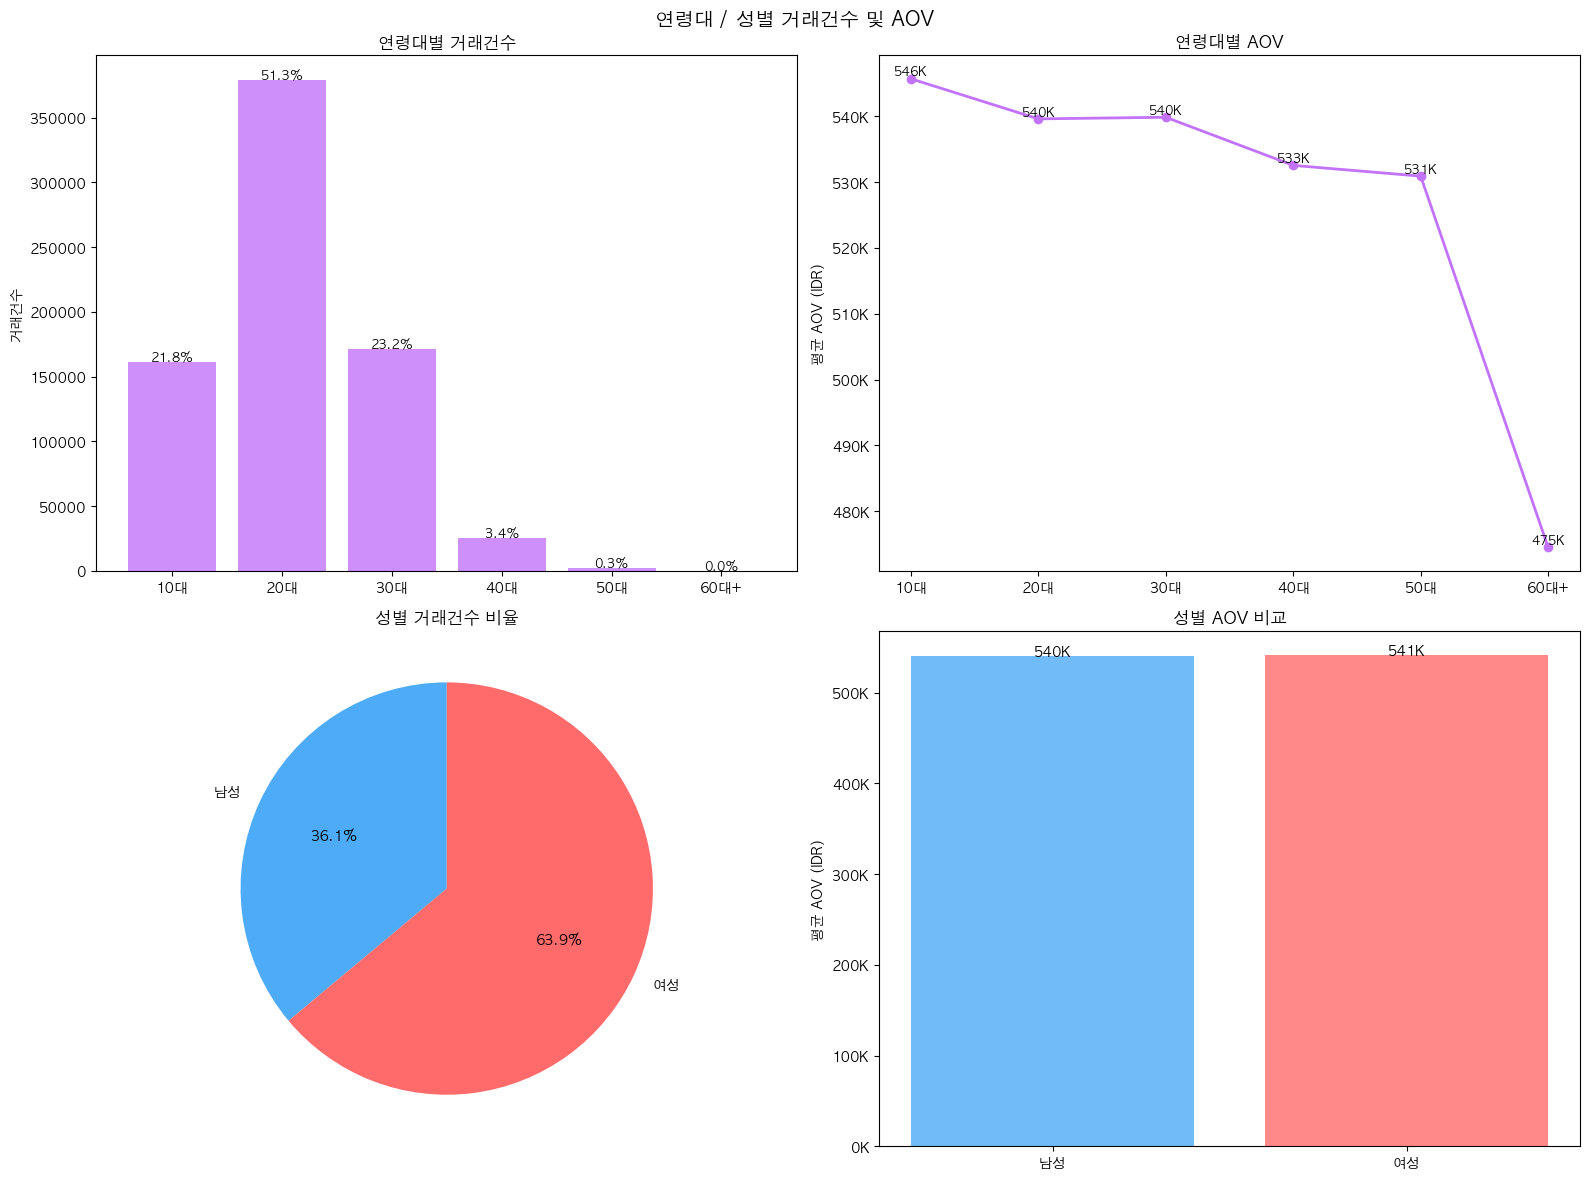

In [237]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 차트 1 - 연령대별 거래건수 + 비율 레이블
bars = axes[0][0].bar(age_group_summary['age_group'],
                      age_group_summary['count'],
                      color="#C273FA", alpha=0.8)
for bar, ratio in zip(bars, age_group_summary['ratio']):
    axes[0][0].text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 1000,
                    f'{ratio:.1f}%', ha='center', fontsize=9)
axes[0][0].set_title('연령대별 거래건수')
axes[0][0].set_ylabel('거래건수')

# 차트 2 - 연령대별 AOV
axes[0][1].plot(age_group_summary['age_group'],
                age_group_summary['aov_mean'],
                marker='o', color="#C273FA", linewidth=2)
for i, v in enumerate(age_group_summary['aov_mean']):
    axes[0][1].text(i, v + 500, f'{v/1000:.0f}K',
                    ha='center', fontsize=9)
axes[0][1].set_title('연령대별 AOV')
axes[0][1].set_ylabel('평균 AOV (IDR)')
axes[0][1].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'{x/1000:.0f}K')
)

# 차트 3 - 성별 거래건수 파이
axes[1][0].pie(gender_summary['count'],
               labels=gender_summary['gender'],
               autopct='%1.1f%%',
               colors=['#4DABF7', '#FF6B6B'],
               startangle=90)
axes[1][0].set_title('성별 거래건수 비율')

# 차트 4 - 성별 AOV 막대
bars = axes[1][1].bar(gender_summary['gender'],
                      gender_summary['aov_mean'],
                      color=['#4DABF7', '#FF6B6B'], alpha=0.8)
for bar, val in zip(bars, gender_summary['aov_mean']):
    axes[1][1].text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 500,
                    f'{val/1000:.0f}K', ha='center', fontsize=10)
axes[1][1].set_title('성별 AOV 비교')
axes[1][1].set_ylabel('평균 AOV (IDR)')
axes[1][1].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'{x/1000:.0f}K')
)

plt.suptitle('연령대 / 성별 거래건수 및 AOV', fontsize=14)
plt.tight_layout()
plt.show()

#### 연령대별 성별 분석 결과
1. 거래량
   - 20대 51.3%로 압도적 1위
   - 10대(21.8%), 30대(23.2%)가 나머지 대부분
   - 여성 63.9%, 남성 36.1%로 전 연령대에서 여성 비율 높음
   - 40대 이상 3.7%로 극히 적음

2. AOV
   - 연령대별 10대~30대 540K 내외로 유사, 40대 이후 점진적 감소
   - 성별 남성 540K, 여성 541K → 차이 1K로 유의미한 차이 없음
   - 60대+ 475K로 가장 낮음 (표본 59건으로 신뢰 어려움)

#### ⇒ 주력 고객층은 20대 여성 (전체 거래 96%가 10~30대)
#### ⇒ 연령대/성별 각각 AOV 차이 미미
#### ⇒ 세분화 해서 보기 위해  연령대와 성별을 교차해서 확인

In [255]:
# 연령대별 AOV
age_gender = transactions.merge(
    customer[['customer_id', 'age_group', 'gender']],
    on='customer_id', how='left'
).groupby(['age_group','gender']).agg(
    order_count=('booking_id', 'count'),
    aov_mean=('net_amount', 'mean'),
    aov_median=('net_amount', 'median')
).reset_index()

# 100% 비율용 피벗
age_pivot = age_gender.pivot(
    index='age_group', columns='gender', values='order_count'
).fillna(0)
age_pivot_pct = age_pivot.div(age_pivot.sum(axis=1), axis=0) * 100

# 남/여 분리
male_data = age_gender[age_gender['gender'] == '남성'].set_index('age_group')
female_data = age_gender[age_gender['gender'] == '여성'].set_index('age_group')

print(age_gender)
print(age_pivot_pct)

   age_group gender  order_count  aov_mean  aov_median
0        10대     남성        57685 544018.54   292653.00
1        10대     여성       103386 546631.04   293962.50
2        20대     남성       137313 537975.44   292946.00
3        20대     여성       241827 540523.81   293687.00
4        30대     남성        62445 543176.95   294354.00
5        30대     여성       108912 537939.89   294357.00
6        40대     남성         8347 528064.03   292482.00
7        40대     여성        16900 534745.37   292560.00
8        50대     남성          804 520243.38   287895.50
9        50대     여성         1361 537200.48   292091.00
10      60대+     남성           33 583083.03   239935.00
11      60대+     여성           26 336707.04   230517.00
gender       남성    여성
age_group            
10대       35.81 64.19
20대       36.22 63.78
30대       36.44 63.56
40대       33.06 66.94
50대       37.14 62.86
60대+      55.93 44.07


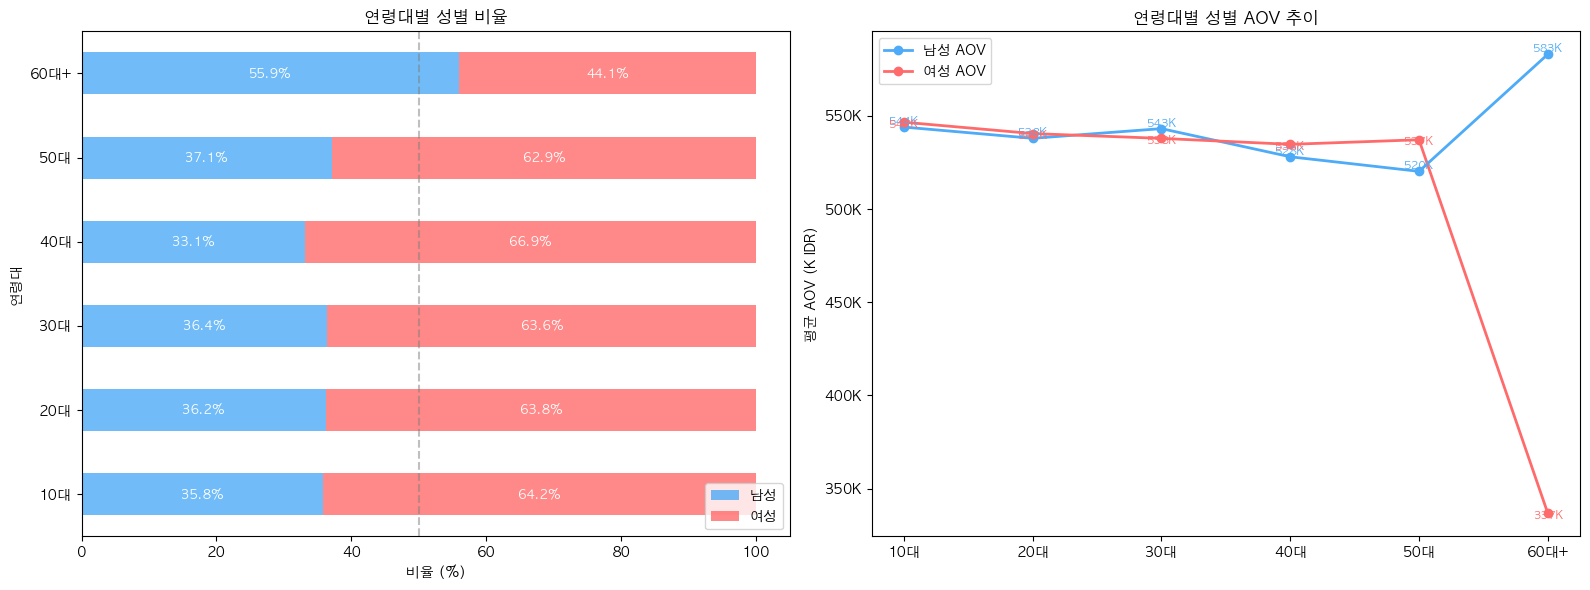

In [ ]:
age_groups = ['10대', '20대', '30대', '40대', '50대', '60대+']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 차트 1 - 100% 누적 가로 막대
age_pivot_pct.plot(kind='barh', stacked=True,
                   color=['#4DABF7', '#FF6B6B'],
                   ax=axes[0], alpha=0.8)

# 값 레이블 추가
for i, (idx, row) in enumerate(age_pivot_pct.iterrows()):
    cumsum = 0
    for col, val in row.items():
        if val > 0:
            axes[0].text(cumsum + val/2, i, f'{val:.1f}%',
                        ha='center', va='center', fontsize=9, color='white')
        cumsum += val

axes[0].set_title('연령대별 성별 비율')
axes[0].set_xlabel('비율 (%)')
axes[0].set_ylabel('연령대')
axes[0].axvline(x=50, color='gray', linestyle='--', alpha=0.5)
axes[0].legend(loc='lower right')

# 차트 2 - 남/여 AOV 꺽은선
x = range(len(age_groups))

aov_male = transactions.merge(
    customer[['customer_id', 'age_group', 'gender']],
    on='customer_id', how='left'
).groupby(['age_group', 'gender'])['net_amount'].mean().reset_index()


male_aov = aov_male[aov_male['gender'] == '남성'].set_index('age_group')
female_aov = aov_male[aov_male['gender_'] == '여성'].set_index('age_group')

axes[1].plot(x,
             [male_aov.loc[a, 'net_amount'] if a in male_aov.index else 0 for a in age_groups],
             marker='o', color='#4DABF7', linewidth=2, label='남성 AOV')
axes[1].plot(x,
             [female_aov.loc[a, 'net_amount'] if a in female_aov.index else 0 for a in age_groups],
             marker='o', color='#FF6B6B', linewidth=2, label='여성 AOV')

# 값 레이블
for i, a in enumerate(age_groups):
    if a in male_aov.index:
        axes[1].text(i, male_aov.loc[a, 'net_amount'] + 1000,
                    f'{male_aov.loc[a, "net_amount"]/1000:.0f}K',
                    ha='center', fontsize=8, color='#4DABF7')
    if a in female_aov.index:
        axes[1].text(i, female_aov.loc[a, 'net_amount'] - 3000,
                    f'{female_aov.loc[a, "net_amount"]/1000:.0f}K',
                    ha='center', fontsize=8, color='#FF6B6B')

axes[1].set_ylabel('평균 AOV (K IDR)')
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(age_groups)
axes[1].set_title('연령대별 성별 AOV 추이')
axes[1].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'{x/1000:.0f}K')
)
axes[1].legend()

plt.tight_layout()
plt.show()

#### 연령대 x 성별 분석 결과

1. 연령대 x 성별 비율
   - 대부분 연령대에서 여성 비율 60% 이상으로 일정
   - 60대+만 남성 55.9%로 역전 (표본 59건으로 신뢰 어려움)

2. 연령대 x 성별 AOV
   - 10대~50대 남녀 AOV 모두 530~550K 내외로 유사
   - 60대+ 남성 AOV 583K로 급등, 여성 333K로 급락
   - 단, 60대+ 표본 부족으로 신뢰 어려움

#### ⇒ 연령대와 성별을 교차해도 AOV 차이 없음
#### ⇒ 그렇다면 연령대의 카테고리별로 구매 패턴이 다른가? 타겟 전략 수립을 위해 확인

In [269]:
# 연령대 + 성별 + 카테고리 조합
segment_category = transactions_premium_Category.merge(
    customer[['customer_id', 'age_group', 'gender']],
    on='customer_id', how='left'
)

# 카테고리별 상품 금액 계산
segment_category['category_amount'] = segment_category['item_price'] * segment_category['quantity']

# 연령대 + 성별 + 카테고리별 집계
seg_cat_agg = segment_category.groupby(
    ['age_group', 'gender', 'masterCategory']
).agg(
    order_count=('booking_id', 'nunique'),
    category_aov_mean=('category_amount', 'mean')
).reset_index()

# 연령대 + 성별별 카테고리 판매수 및 AOV
sort_category = seg_cat_agg.sort_values(
    ['category_aov_mean','order_count'],
    ascending=[False,False]
)

print(sort_category)

   age_group gender  masterCategory  order_count  category_aov_mean
56       50대     남성      Free Items            5         1214628.20
24       20대     여성            Home            7          503697.57
5        10대     남성  Sporting Goods           35          494658.20
66      60대+     남성         Apparel           17          442695.11
44       40대     남성      Free Items           24          428895.92
65      60대+     남성     Accessories            9          418443.00
61       50대     여성        Footwear          371          392035.57
54       50대     남성         Apparel          455          386123.91
23       20대     여성      Free Items          868          384981.47
4        10대     남성   Personal Care         4289          380872.66
10       10대     여성            Home            4          377721.25
27       30대     남성     Accessories        19516          376129.84
32       30대     남성   Personal Care         4734          375131.12
11       10대     여성   Personal Care         7895

In [285]:
seg_cat_agg[['age_group', 'gender', 'masterCategory', 'order_count', 'category_aov_mean']].sort_values(['masterCategory', 'category_aov_mean','age_group','gender'], ascending=[True, False, True, False])

,age_group,gender,masterCategory,order_count,category_aov_mean
65,60대+,남성,Accessories,9,418443.00
27,30대,남성,Accessories,19516,376129.84
47,40대,여성,Accessories,5283,374211.87
0,10대,남성,Accessories,17959,371747.02
6,10대,여성,Accessories,31964,371741.19
34,30대,여성,Accessories,33908,371130.05
13,20대,남성,Accessories,42589,367456.44
20,20대,여성,Accessories,75172,367176.98
53,50대,남성,Accessories,230,365300.55
41,40대,남성,Accessories,2637,357161.45


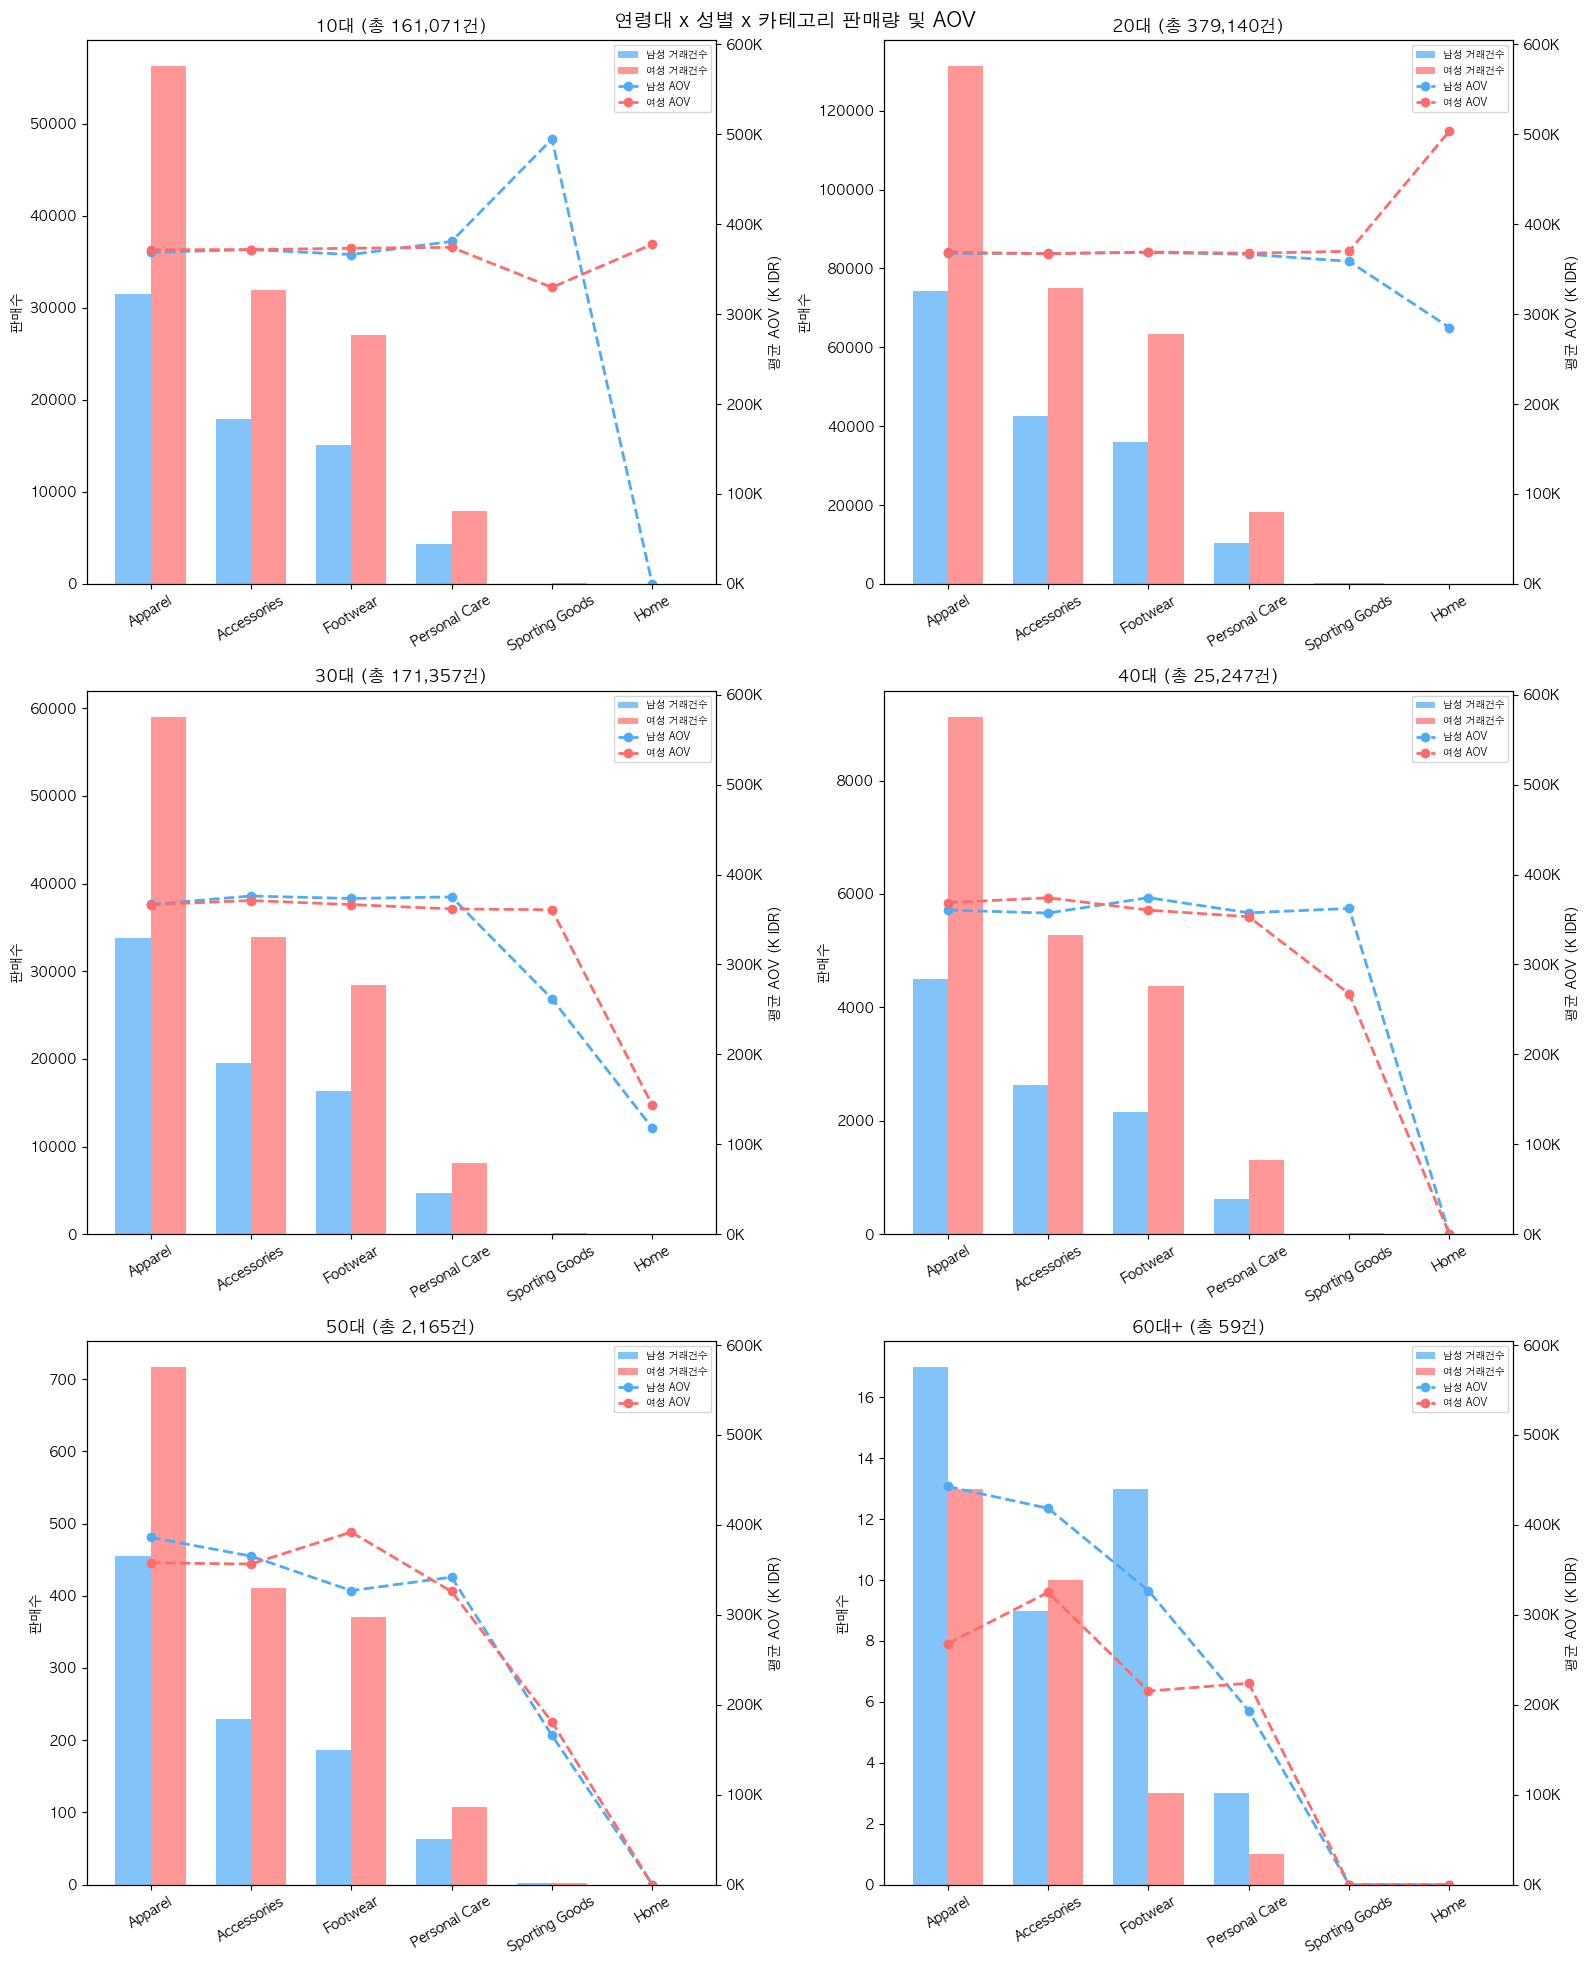

In [274]:
age_groups = ['10대', '20대', '30대', '40대', '50대', '60대+']
categories = ['Apparel', 'Accessories', 'Footwear', 
              'Personal Care', 'Sporting Goods', 'Home']
aov_max = seg_cat_agg[seg_cat_agg['masterCategory'].isin(categories)]['category_aov_mean'].max() * 1.2
cnt_max = seg_cat_agg['order_count'].max() * 1.05

fig, axes = plt.subplots(3, 2, figsize=(16, 20))

for idx, age in enumerate(age_groups):
    ax1 = axes[idx//2][idx%2]
    
    data = seg_cat_agg[
        (seg_cat_agg['age_group'] == age) &
        (seg_cat_agg['masterCategory'].isin(categories))
    ]
    
    male = data[data['gender'] == '남성'].set_index('masterCategory')
    female = data[data['gender'] == '여성'].set_index('masterCategory')
    total = age_group_summary[age_group_summary['age_group'] == age]['count'].sum()

    x = range(len(categories))
    width = 0.35
    
    ax1.bar([i - width/2 for i in x],
            [male.loc[c, 'order_count'] if c in male.index else 0 for c in categories],
            width=width, color='#4DABF7', alpha=0.7, label='남성 거래건수')
    ax1.bar([i + width/2 for i in x],
            [female.loc[c, 'order_count'] if c in female.index else 0 for c in categories],
            width=width, color='#FF6B6B', alpha=0.7, label='여성 거래건수')
    ax1.set_ylabel('판매수')
    ax1.set_xticks(list(x))
    ax1.set_xticklabels(categories, rotation=30)
    
    ax1.set_title(f'{age} (총 {total:,}건)')
    #ax1.set_ylim(0, cnt_max)
    
    
    ax2 = ax1.twinx()
    ax2.plot(x, [male.loc[c, 'category_aov_mean'] if c in male.index else 0 for c in categories],
             marker='o', color='#4DABF7', linewidth=2, linestyle='--', label='남성 AOV')
    ax2.plot(x, [female.loc[c, 'category_aov_mean'] if c in female.index else 0 for c in categories],
             marker='o', color='#FF6B6B', linewidth=2, linestyle='--', label='여성 AOV')
    ax2.set_ylabel('평균 AOV (K IDR)')
    ax2.set_ylim(0, aov_max)
    ax2.yaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, p: f'{x/1000:.0f}K')
    )
    
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2,
               loc='upper right', fontsize=7)

plt.suptitle('연령대 x 성별 x 카테고리 판매량 및 AOV', fontsize=14)
plt.tight_layout()
plt.show()

#### 연령대 x 성별 x 카테고리 분석 결과

1. 전 연령대 공통
   - Apparel, Accessories, Footwear가 판매량 상위 3개 카테고리
   - 대부분 연령대에서 여성 판매량이 남성보다 많음

2. AOV 패턴
   - 카테고리별, 연령대별, 성별 AOV 차이가 거의 없음 (300~400K 범위로 유사)
   - 특정 세그먼트나 카테고리가 AOV를 낮추거나 높이는 패턴은 확인되지 않음
   - Sporting Goods / Home은 일부 세그먼트에서 높은 AOV가 관측  
     그러나 판매량이 극소량이라 전체 AOV에 영향은 제한적임  
   - 따라서 AOV 정체는 세그먼트 구성의 문제로 보기 어려움

3. 연령대별 특이사항
   - 10대-30대 : 여성 고객의 Apparel 판매량 압도적 → 전체 AOV에 가장 큰 영향을 주는 세그먼트  
                10-20대 Personal Care 판매량이 낮지만 AOV는 평균
   - 10대 남성 : Sporting Goods AOV 494K로 전 세그먼트 높으나 판매량(35건) 표본이 작음
   - 20대 여성 : Home AOV 503K로 높으나 판매량(7건) 표본이 작음
   - 40대 : 판매량 급감
   - 50대 여성 : Footwear AOV가 타 연령대 대비 소폭 높으나 판매량(371건)으로 규모가 작음  
                판매량이 적어 전체 AOV 기여도는 낮음
   - 60대+: 표본 극히 적어 신뢰 어려워 해석에서 제외가 적절

#### ⇒ 특정 세그먼트나 카테고리가 AOV 정체의 주요 원인이라고 보기 어려움
#### ⇒ 10대~30대 여성 Apparel/Accessories/Footwear — 판매량 비중 압도적으로 높아 AOV 개선 실험 적용 시 전체 성과 영향이 가장 큰 핵심 세그먼트
#### ⇒ 50대 여성 Footwear — 표본은 적으나 고가 상품 구매 패턴 확인, 판매량 확대 시 AOV 기여 가능성 있는 잠재 세그먼트
\- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 

### ▸ 세그먼트별 일부 인사이트 확인했으나 AOV 정체의 근본 원인으로는 부족
### ⇒ 퍼널 분석으로 구매 전환 과정 자체를 살펴볼 필요 있음


## 4. 퍼널 분석
-----

###  퍼널 분석 목적
- 3가지 가설 검증 및 세그먼트 분석으로 고객/상품 측면 원인 확인
- 특정 고객층이나 상품 구성이 AOV 정체 원인이 아님을 확인
- 그렇다면 고객이 구매하는 과정 자체에 문제가 있는 것 아닐까?
  - 어느 단계에서 이탈이 발생하는가?
  - 구매 전환 과정에서 AOV를 제한하는 구조가 있는가?

#### ⇒ 전체 퍼널 이탈율 확인
#### ⇒ traffic_source별 퍼널 비교

In [102]:
# 퍼널구성을 위한 데이터 확인
print(click_stream['traffic_source'].value_counts())
print(click_stream['event_name'].value_counts())

traffic_source
MOBILE    10013423
WEB        1112962
Name: count, dtype: int64
event_name
CLICK          2176750
HOMEPAGE       2158372
ADD_TO_CART    1647320
SCROLL         1453921
ITEM_DETAIL    1126164
SEARCH         1026648
BOOKING         740511
PROMO_PAGE      521107
ADD_PROMO       275592
Name: count, dtype: int64


####  퍼널 항목 구성
- 인지 단계  
    → **진인 : HOMEPAGE**

- 탐색 단계  
    → **상세페이지 : ITEM_DETAIL**

- 구매 의도 단계  
    → **장바구니 : ADD_TO_CART**

- 전환 단계  
    → **구매완료 : BOOKING**

In [103]:
# 세션별 최종 도달 단계 파악
funnel_steps = ['HOMEPAGE', 'ITEM_DETAIL', 'ADD_TO_CART', 'BOOKING']

# 세션별 이벤트 목록
session_events = click_stream.groupby('session_id')['event_name'].apply(set).reset_index()

# 각 단계 도달 여부
for step in funnel_steps:
    session_events[step] = session_events['event_name'].apply(
        lambda x: step in x
    )

# HOMEPAGE 방문 세션만 필터링
session_events = session_events[session_events['HOMEPAGE'] == True]

# 단계별 도달 세션 수
funnel_data = []
for step in funnel_steps:
    count = session_events[step].sum()
    funnel_data.append({'step': step, 'sessions': count})

funnel_df = pd.DataFrame(funnel_data)
funnel_df['conversion_rate'] = (
    funnel_df['sessions'] / funnel_df['sessions'].iloc[0] * 100
).round(2)
funnel_df['drop_rate'] = (
    (1 - funnel_df['sessions'] / funnel_df['sessions'].shift(1)) * 100
).round(2)

print(funnel_df)


          step  sessions  conversion_rate  drop_rate
0     HOMEPAGE    769417           100.00        NaN
1  ITEM_DETAIL    450254            58.52      41.48
2  ADD_TO_CART    751386            97.66     -66.88
3      BOOKING    738248            95.95       1.75


#### ⇒ ITEM_DETAIL이 ADD_TO_CART가 더 많은걸 확인 
- HOMEPAGE → ITEM_DETAIL 이탈 41% (가장 많음)
- 세션 수는 [ADD_TO_CART] > [ITEM_DETAIL]  
- 상세페이지를 거치지 않고 바로 장바구니에 넣는 UX구조가 존재 할 수 있음

In [104]:
# 세션별 ITEM_DETAIL 없이 ADD_TO_CART 바로 간 비율
session_events['skip_detail'] = (
    (session_events['ADD_TO_CART'] == True) & 
    (session_events['ITEM_DETAIL'] == False)
)

total_cart = session_events['ADD_TO_CART'].sum()
skip_detail = session_events['skip_detail'].sum()

print(f"ADD_TO_CART 전체: {total_cart:,}")
print(f"ITEM_DETAIL 없이 ADD_TO_CART: {skip_detail:,}")
print(f"바로 ADD_TO_CART 비율: {skip_detail/total_cart*100:.1f}%")

ADD_TO_CART 전체: 751,386
ITEM_DETAIL 없이 ADD_TO_CART: 309,382
바로 ADD_TO_CART 비율: 41.2%


#### ⇒ ITEM_DETAIL 본 사람 vs 안 본 사람 AOV 비교
 - 상세 페이지 여부가 AOV에 영향 주는가?

In [105]:
# session_id로 transactions 조인
session_detail = session_events[['session_id', 'ITEM_DETAIL']]

transactions_funnel = transactions.merge(
    session_detail, on='session_id', how='left'
)

# ITEM_DETAIL 여부별 AOV 비교
aov_by_detail = transactions_funnel.groupby('ITEM_DETAIL').agg(
    order_count=('booking_id', 'count'),
    aov_mean=('net_amount', 'mean'),
    aov_median=('net_amount', 'median')
).reset_index()

aov_by_detail['detail_type'] = aov_by_detail['ITEM_DETAIL'].map(
    {True: '상세페이지 O', False: '상세페이지 X'}
)

print(aov_by_detail[['detail_type', 'order_count', 'aov_mean', 'aov_median']])

  detail_type  order_count  aov_mean  aov_median
0     상세페이지 X       302460 530679.42   291195.00
1     상세페이지 O       435788 547641.77   295468.00


1. 상세 페이지 여부가 AOV에 영향 주는가?
- 상세페이지에 진입하는 세션이 먆음
- 평균 AOV 차이 약 17,000 IDR (3%)로 상세페이지 진입시 더 높음
- 중앙값 차이 미미 (4,273 IDR)

#### ⇒ 상세페이지 진입 여부가 CVR에도 영향을 주는가?

In [106]:
# 결제 성공 세션
success_sessions = click_stream[
    (click_stream['event_name'] == 'BOOKING') &
    (click_stream['payment_status'] == 'Success')
]['session_id'].unique()

#print(success_sessions)
#print('-'*30)
# session_events에 결제 성공 여부 추가
session_events['purchased'] = session_events['session_id'].isin(success_sessions)
#print(session_events)
#print('-'*30)
# ITEM_DETAIL 여부별 CVR
cvr_by_detail = session_events.groupby('ITEM_DETAIL').agg(
    total_sessions=('session_id', 'count'),
    purchased=('purchased', 'sum')
).reset_index()

cvr_by_detail['cvr'] = (
    cvr_by_detail['purchased'] / 
    cvr_by_detail['total_sessions'] * 100.00
).round(4)

cvr_by_detail['detail_type'] = cvr_by_detail['ITEM_DETAIL'].map(
    {True: '상세페이지 O', False: '상세페이지 X'}
)

print(cvr_by_detail[['detail_type', 'total_sessions', 'purchased', 'cvr']])

  detail_type  total_sessions  purchased   cvr
0     상세페이지 X          319163     289334 90.65
1     상세페이지 O          450254     417186 92.66


1. 상세페이지 진입 여부가 CVR에도 영향을 주는가?
- 상세페이지 진입시 CVR 2.01% 높음

#### ⇒ 상세페이지 진입 여부가 AOV와 CVR에도 미비하지만 영향을 줌

####  **traffic_source별 퍼널 비교**
- MOBILE vs WEB


In [107]:
# traffic_source별 세션 분리
for source in ['MOBILE', 'WEB']:
    source_sessions = click_stream[
        click_stream['traffic_source'] == source
    ]
    
    # 세션별 이벤트 set
    traffic_session_events = source_sessions.groupby('session_id')['event_name'].apply(set).reset_index()
    
    for step in funnel_steps:
        traffic_session_events[step] = traffic_session_events['event_name'].apply(lambda x: step in x)
    
    # HOMEPAGE 기준 필터링
    traffic_session_events = traffic_session_events[traffic_session_events['HOMEPAGE'] == True]
    
    funnel_data = []
    for step in funnel_steps:
        count = traffic_session_events[step].sum()
        funnel_data.append({'step': step, 'sessions': count})
    
    funnel_source = pd.DataFrame(funnel_data)
    funnel_source['conversion_rate'] = (
        funnel_source['sessions'] / funnel_source['sessions'].iloc[0] * 100
    ).round(2)
    funnel_source['drop_rate'] = (
        (1 - funnel_source['sessions'] / funnel_source['sessions'].shift(1)) * 100
    ).round(2)
    
    print(f"\n{'='*40}")
    print(f"[{source}]")
    print(funnel_source)

# traffic_source별 AOV
aov_by_source = transactions.merge(
    click_stream[['session_id', 'traffic_source']].drop_duplicates(),
    on='session_id', how='left'
).groupby('traffic_source').agg(
    order_count=('booking_id', 'count'),
    aov_mean=('net_amount', 'mean'),
    aov_median=('net_amount', 'median')
).reset_index()

print("\n[traffic_source별 AOV]")
print(aov_by_source)


[MOBILE]
          step  sessions  conversion_rate  drop_rate
0     HOMEPAGE    692341           100.00        NaN
1  ITEM_DETAIL    405205            58.53      41.47
2  ADD_TO_CART    676083            97.65     -66.85
3      BOOKING    664297            95.95       1.74

[WEB]
          step  sessions  conversion_rate  drop_rate
0     HOMEPAGE     77076           100.00        NaN
1  ITEM_DETAIL     45049            58.45      41.55
2  ADD_TO_CART     75303            97.70     -67.16
3      BOOKING     73951            95.95       1.80

[traffic_source별 AOV]
  traffic_source  order_count  aov_mean  aov_median
0         MOBILE       666327 540816.81   293547.00
1            WEB        74184 539566.99   294269.50


1. MOBILE vs WEB 전환율/이탈율 비교 및 AOV 영향
- MOBILE vs WEB 퍼널 전환율/이탈율 거의 동일
- AOV 차이 약 1,250 IDR (0.2%) → 유의미한 차이 없음
- 유입 채널에 따른 구매 패턴 차이 없음

### 퍼널 분석 결과
1. 전체 퍼널
   - HOMEPAGE → ITEM_DETAIL 이탈 41% (핵심 이탈 구간)
   - ADD_TO_CART → BOOKING 이탈 2% (구매 의도 높음)

2. 상세페이지 여부별 분석
   - 상세페이지 진입 시 AOV 3% 높음 (547,642 vs 530,679)
   - 상세페이지 진입 시 CVR 2%p 높음 (92.66% vs 90.65%)
   - 상세페이지 진입 유도가 CVR + AOV 동시 개선 가능

3. traffic_source별
   - MOBILE vs WEB 퍼널/AOV 차이 없음
   - 유입 채널은 구매 패턴에 영향 없음

#### 종합
>   - HOMEPAGE → ITEM_DETAIL 41% 이탈이 핵심 개선 포인트  
>   - 상세페이지 진입 유도 시 CVR + AOV 동시 개선 기대

## 5. 전략 제안
---

### 분석 종합
> 가설 검증, 세그먼트, 퍼널 분석 결과를 종합해 실행 우선순위 기반으로 정리

---

### 단기 (즉시 실행)

- **홈페이지 UX 개선** *(퍼널 분석)*  
  HOMEPAGE → ITEM_DETAIL 41% 이탈 구간 개선  
  상품 카드 퀵뷰, 이미지 호버 확대, CTA 강화로 상세페이지 진입 유도  
  

- **프로모션 구조 개선** *(가설 B)*  
  현재 프로모션은 전환 유도에는 기여하지만,  
  고율 할인 구간이 저가 상품 중심으로 형성되어 AOV 상승 효과는 제한적임  
  → 3-5%+ 고율 할인 구간 거래 비율을 줄이기   
  → 1-3% 소폭 할인을 고가 상품에 적용해 AOV 유지하며 신규 유입 도모  
  
> **⇒ 효과 검증은 A/B 테스트 설계 참고 (6번)**

---

### 중기 (1-3개월)

- **핵심 세그먼트 집중 공략** *(세그먼트 × 퍼널)*  
  10대~30대 여성 Apparel / Accessories / Footwear  
  AOV와 거래량을 함께 고려했을 때 우선순위가 높은 핵심 세그먼트  
  → UX 개선(상세페이지 진입 유도)을 이 세그먼트에 집중 적용  
  → 개선 전후 ITEM_DETAIL 진입률 · AOV · CVR 비교로 인과 검증

- **번들 / 업셀 도입** *(세그먼트 × 프로모션)*  
  핵심 세그먼트(10~30대) Apparel 구매 시 Accessories 번들 추천  
  → 재구매 고객 대상 업셀·크로스셀로 AOV 견인

---

### 장기 (3개월 이상)

- **잠재 세그먼트 유입 확대** *(세그먼트 × 프로모션 × 퍼널)*  
  50대 여성 Footwear — 표본은 적으나 고가 상품 구매 패턴 확인   
  → 타겟 프로모션(첫 구매 할인, 무료 배송)으로 유입량 확대 실험  
  → 상세페이지 진입 유도 랜딩 연결 → 구매 전환까지 퍼널 추적  
  → 세그먼트 + 프로모션 + 퍼널 3가지 분석을 하나의 캠페인으로 통합 검증  
  > ⚠️ 거래량 부족 원인(인지도/채널 문제)은 현재 데이터로 확인 불가  
  > 가능하면, 유입 경로 데이터, 광고 타겟팅 로그 추가 확인 필요

- **재구매 고객 번들 추천 고도화** *(코호트 × 번들)*  
  코호트 리텐션이 유지되고 있는 재구매 고객 대상 구매 횟수별 맞춤 번들  
  → 5회 이상 재구매 고객에게 Accessories 번들 제안  
  → AOV 업리프트 + 고객 생애 가치(LTV) 제고

## 6. A/B 테스트 설계
---

### 테스트 1. 홈페이지 UX 개선
**목적** : 홈 화면 UI 개선이 ITEM_DETAIL 진입율과 AOV에 미치는 영향 검증

| 구분 | 내용 |
|------|------|
| 대조군 (A) | 기존 홈 화면 레이아웃 유지 |
| 실험군 (B) | 상품 카드 퀵뷰, 이미지 호버 확대, CTA 강화 적용 |
| 측정 지표 | ITEM_DETAIL 진입율, CVR, 세션당 AOV |
| 테스트 기간 | 4주 |
| 성공 기준 | ITEM_DETAIL 진입율 +3~5%p 개선, CVR 및 AOV 하락 없음|

---

### 테스트 2. 프로모션 구조 개선
**목적** : 고가 상품 한정 소폭 할인이 AOV 희석 없이 신규 유입에 미치는 영향 검증

| 구분 | 내용 |
|------|------|
| 대조군 (A) | 기존 할인 정책 유지 (고율 할인 저가 상품 중심) |
| 실험군 (B) | 주력 카테고리 고가 상품 한정 소폭 할인(1~3%) 적용 |
| 측정 지표 | AOV, CVR, 신규 유입 고객 수, 매출 |
| 테스트 기간 | 4주 |
| 성공 기준 | 실험군 AOV +2~3% 개선, 신규 유입 고객 수 유지 또는 증가 |

## 7. 성과 측정 기준 (KPI)
---


| 분석 연계 | 지표 | 현재 | 목표 | 측정 방법 | 측정 주기 |
|------|------|------|------|------|------|
| 핵심 지표 | AOV (net) | 540,000 IDR | +2~3% 개선 | net_amount / order_cnt | 월별 |
| 퍼널 분석 | ITEM_DETAIL 진입율 | 59% | +3~5%p 개선 | ITEM_DETAIL 세션 / HOMEPAGE 세션 | 월별 |
| 퍼널 분석 | 전체 CVR | 91~93% | 현행 유지 또는 +1%p | BOOKING 성공 / HOMEPAGE 세션 | 월별 |
| 프로모션 | 고율 할인 거래 비율 | 3~5%+ 구간 | 감소 추세 | 할인율 구간별 거래 비율 | 월별 |
| 세그먼트 | 핵심 세그먼트 AOV | 539,000 IDR | 현행 유지 또는 +2% | 10~30대 여성 월별 AOV | 월별 |
| 세그먼트 | 잠재 세그먼트 거래건수 | 1,361건 | 전월 대비 +20% | 50대 여성 월별 거래 건수 | 월별 |
| 리텐션 | 3개월 리텐션율 | 35.8% | 현행 유지 또는 +2%p | 코호트 3개월 재구매 비율 | 월별 |

## 8. Tableau Dashboard
---

분석 결과를 시각화한 대시보드를 아래 링크에서 확인할 수 있습니다.

- **링크** : [Tableau Public 바로가기](https://public.tableau.com/여기에주소)
- **구성** : 비즈니스 현황 / 가설 검증 / 세그먼트 분석 / 퍼널 분석 / KPI 모니터링

In [ ]:
transactions.to_csv("output/transactions.csv", index=False, encoding='utf-8-sig')
click_stream.to_csv("output/click_stream.csv", index=False, encoding='utf-8-sig')
customer.to_csv("output/customer.csv", index=False, encoding='utf-8-sig')
product.to_csv("output/product.csv", index=False, encoding='utf-8-sig')